# Progetto MIGA — Sistema di Raccomandazione e Sentiment Analysis
### Amazon Reviews 2023 — categoria **Movies_and_TV** · Livello AVANZATO

Notebook unico con le tre fasi del progetto, costruite in modo incrementale:
1. **BASE** — Collaborative Filtering (Surprise: K-NN, SVD, K-Means, top-N)
2. **INTERMEDIA** — Content-Based (TF-IDF + transformer, K-NN per utente)
3. **AVANZATA** — Sentiment Analysis (classificatori del Lab 6, gestione dello sbilanciamento, bonus LLM)

Il dataset viene caricato in streaming via link `hf://` da HuggingFace, quindi non serve caricare file a mano.

---
### Come eseguire su Google Colab
1. Aprire il notebook con **Google Colaboratory**.
2. Attivare la **GPU**: *Runtime -> Cambia tipo di runtime -> GPU (T4)*.
3. *Runtime -> Esegui tutto*. Il setup non richiede riavvii del kernel.
4. Alla cella 3.13 (bonus LLM) viene chiesta la `GROQ_API_KEY`: incollarla al prompt.
   Premendo solo invio il notebook usa il fallback HuggingFace zero-shot.
5. (Opzionale) per salvare figure e tabelle su Google Drive, impostare `MOUNT_DRIVE = True`
   nella cella 0.2. Consigliato se si teme che la sessione cada: i risultati sopravvivono.

### Se il runtime si riavvia (crash di RAM, disconnessione)
Il notebook salva su disco ogni risultato importante (parquet, `.npy`, `risultati_chiave.json`),
quindi **non serve rifare tutto**:
1. rieseguire le celle **0, 0.1, 0.2** (installazione, configurazione, cartelle);
2. riprendere dalla parte dove si era interrotto: ogni parte ricarica da disco cio che le serve;
3. per il solo **Capitolo 8**, eseguire la cella **8.0** che ripristina tutto il necessario.

## 0. Installazione delle librerie
Installo solo cio che manca su Colab. `scikit-surprise` viene compilato contro il NumPy gia
presente nel runtime (`--no-build-isolation`), quindi la ABI e coerente e **non serve alcun
riavvio del kernel**.

In [1]:
# ================= SETUP (una sola cella, NIENTE riavvio) =================
# scikit-surprise viene compilato contro il NumPy gia presente su Colab
# (--no-build-isolation): stessa ABI a compile-time e a run-time, quindi
# nessun mismatch "dtype size changed" e nessun bisogno di riavviare il kernel.
import subprocess, sys, importlib

def _presente(modulo):
    try:
        importlib.import_module(modulo); return True
    except ImportError:
        return False

def _pip(args):
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check", *args],
        check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
    )

# scikit-surprise: se non c'e, lo compilo contro il NumPy corrente
if not _presente("surprise"):
    _pip(["--only-binary=:all:", "Cython"])
    _pip(["--no-build-isolation", "scikit-surprise"])

# Altri pacchetti che potrebbero mancare (nessuno tocca il NumPy caricato).
# sentence_transformers serve al capitolo 8.3 e su Colab NON e preinstallato.
_da_installare = []
if not _presente("datasets"):              _da_installare.append("datasets<3.0.0")
if not _presente("fsspec"):                _da_installare.append("fsspec<=2024.6.1")
if not _presente("imblearn"):              _da_installare.append("imbalanced-learn")
if not _presente("langchain_groq"):        _da_installare.append("langchain-groq")
if not _presente("sentence_transformers"): _da_installare.append("sentence-transformers")

if _da_installare:
    print("Installo:", ", ".join(_da_installare))
    _pip(_da_installare)

import numpy, surprise, sklearn, warnings
warnings.filterwarnings("ignore")  # silenzia i FutureWarning di fsspec/datasets/sklearn
print(f"Setup pronto | Python {sys.version.split()[0]} | NumPy {numpy.__version__} "
      f"| scikit-surprise {surprise.__version__} | scikit-learn {sklearn.__version__} | nessun riavvio.")

Installo: langchain-groq
Setup pronto | Python 3.13.15 | NumPy 2.1.3 | scikit-surprise 1.1.5 | scikit-learn 1.6.1 | nessun riavvio.


## 0.1 — Configurazione globale
Tengo tutti i parametri del progetto in un unico punto, cosi da poterli cambiare senza toccare il resto del codice.

In [2]:
# ============ CONFIGURAZIONE GLOBALE ============
# Tutti i parametri del progetto stanno qui: cambiare categoria o soglie non
# richiede di toccare nessun'altra cella.
RANDOM_STATE = 42
CATEGORY     = "Movies_and_TV"

# --- BASE (collaborative filtering) ---
MAX_REVIEWS  = 1000000           # recensioni scaricate in streaming
K_CORE       = 5                 # soglia k-core
CV_FOLDS     = 5                 # k-fold cross validation (Lab 8)
TOP_N        = 10                # lunghezza liste di raccomandazione
USERS_CAP    = 4000              # utenti piu attivi tenuti: limita la matrice di similarita user-user
ITEMS_CAP    = 12500             # prodotti piu recensiti tenuti: limita la matrice item-item (RAM)
UTENTI_FILL  = 200               # utenti per cui materializzo il filling della matrice
MAX_UTENTI_TOPN = 2000           # utenti per cui genero le liste top-N
MAX_CANDIDATI   = 5000           # candidati estratti a caso quando i non-visti sono troppi

# --- INTERMEDIA (content-based) ---
KNN_K           = 40             # vicini per il content-based (Lab 8)
HF_MODEL_EMB    = "distilbert-base-uncased"                  # transformer per gli embedding (Lab 10)
HF_MODEL_ST     = "sentence-transformers/all-mpnet-base-v2"  # sentence-transformer (cap. 8.3)

# --- AVANZATA (sentiment) ---
SAMPLE_SIZE        = 40000       # recensioni campionate per la sentiment
TFIDF_MAX_FEATURES = 10000       # termini TF-IDF per la sentiment
TFIDF_MAX_FEAT_CB  = 20000       # termini TF-IDF per il content-based
GROQ_MODEL         = "openai/gpt-oss-20b"   # LLM per il bonus (Lab 11, Groq)
N_LLM              = 300         # recensioni per il bonus LLM

import numpy as np
np.random.seed(RANDOM_STATE)
print("Config OK - categoria:", CATEGORY)

Config OK - categoria: Movies_and_TV


## 0.2 — Import, Google Drive (opzionale) e cartelle di output
Import di base, seed fissato per la riproducibilità, cartelle di output e un checkpoint su disco (risultati_chiave.json) dove salvo tutti i numeri del report man mano che li calcolo. MOUNT_DRIVE è il flag per salvare su Google Drive: lo tengo a False per far girare "Esegui tutto" senza il popup di autorizzazione.

In [3]:
import os, re, gc, time, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["savefig.dpi"] = 150

# Metti True per salvare figure/dati su Google Drive (verra chiesto l'accesso).
# Consigliato se la sessione rischia di cadere: cosi i risultati sopravvivono al riavvio.
MOUNT_DRIVE = False
if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/Progetto_MIGA_Movies"
else:
    BASE_DIR = "."

DATA_DIR = os.path.join(BASE_DIR, "dataset")
FIG_DIR  = os.path.join(BASE_DIR, "report", "figure")
RES_DIR  = os.path.join(BASE_DIR, "report", "risultati")
for d in [DATA_DIR, FIG_DIR, RES_DIR]:
    os.makedirs(d, exist_ok=True)

def salva_fig(nome):
    p = os.path.join(FIG_DIR, nome); plt.savefig(p, bbox_inches="tight"); print("[figura]", p)

def salva_tab(df, nome):
    p = os.path.join(FIG_DIR, nome); df.to_csv(p, index=False); print("[tabella]", p)

# ---- Checkpoint dei risultati -------------------------------------------------
# Ogni numero che finisce nel report viene scritto qui appena calcolato. Serve a due cose:
#  1) se il runtime si riavvia, il Capitolo 8 (cella 8.0) ripesca i valori senza rifare i grid;
#  2) alla fine ho un unico file con tutti i numeri del report, senza doverli ricopiare a mano.
PATH_RES = os.path.join(RES_DIR, "risultati_chiave.json")

def leggi_risultati():
    if os.path.exists(PATH_RES):
        with open(PATH_RES, encoding="utf-8") as f:
            return json.load(f)
    return {}

def salva_risultato(chiave, valore):
    r = leggi_risultati()
    r[chiave] = valore
    with open(PATH_RES, "w", encoding="utf-8") as f:
        json.dump(r, f, indent=2, ensure_ascii=False, default=str)
    return valore

def libera(*nomi):
    """Elimina variabili pesanti dal namespace e forza la garbage collection."""
    g = globals()
    for n in nomi:
        if n in g:
            del g[n]
    gc.collect()

ID_UTENTE, ID_ITEM = "user_id", "item_id"
print("Setup pronto. Output in:", os.path.abspath(BASE_DIR))
print("Checkpoint risultati:", PATH_RES)

Setup pronto. Output in: /content
Checkpoint risultati: ./report/risultati/risultati_chiave.json


# PARTE 1 - Collaborative Filtering (BASE)

_Corrisponde ai **capitoli 1-4** del report: descrizione dati (cap. 1), EDA (cap. 2), preparazione k-core e cap dimensionali (cap. 3), K-NN e SVD sulla matrice dei voti + K-Means (cap. 4)._

## 1.1 — Caricamento del dataset (recensioni)
Carico le recensioni in streaming via link `hf://`, tenendo solo i campi che servono al
collaborative filtering (senza testo e immagini, per non saturare la memoria). Come identificativo
di prodotto uso **`parent_asin`**, che raggruppa le varianti dello stesso titolo.

In [4]:
from datasets import load_dataset

# Nel file delle recensioni il campo si chiama "helpful_vote" (singolare), come da traccia.
# Leggo entrambe le grafie per sicurezza: chiedere solo "helpful_votes" restituirebbe
# sempre None e la colonna resterebbe vuota, falsando l'analisi di correlazione.
CAMPI_REVIEW = ["user_id", "parent_asin", "asin", "rating", "timestamp",
                "helpful_vote", "verified_purchase"]

def carica_recensioni(category, max_rows=MAX_REVIEWS):
    url = f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/{category}.jsonl"
    ds = load_dataset("json", data_files=url, split="train", streaming=True)
    ds = ds.shuffle(seed=RANDOM_STATE, buffer_size=100000)

    # Tengo solo i campi che servono (niente testo/immagini): memoria sotto controllo
    righe = []
    for ex in ds:
        r = {k: ex.get(k) for k in CAMPI_REVIEW}
        if r["helpful_vote"] is None:              # alcune release usano il plurale
            r["helpful_vote"] = ex.get("helpful_votes")
        righe.append(r)
        if len(righe) >= max_rows:
            break
    return pd.DataFrame(righe)

print(f"Scarico fino a {MAX_REVIEWS:,} recensioni di {CATEGORY}...")
t0 = time.time()
df = carica_recensioni(CATEGORY)
print(f"Scaricate in {(time.time()-t0)/60:.1f} min")

# item_id = parent_asin (fallback su asin se mancante)
df["item_id"] = df["parent_asin"].fillna(df["asin"])
df = df.dropna(subset=["user_id", "item_id", "rating"])
df["rating"] = df["rating"].astype("float32")
df["verified_int"] = df["verified_purchase"].fillna(False).astype("int8")
df["helpful_vote"] = pd.to_numeric(df["helpful_vote"], errors="coerce").fillna(0).astype("int32")

# Verifica esplicita che il campo sia davvero valorizzato (era il bug della versione precedente)
non_nulli = int((df["helpful_vote"] > 0).sum())
print(f"helpful_vote valorizzato: {non_nulli:,} recensioni con almeno 1 voto utile "
      f"({non_nulli/len(df)*100:.1f}%) | massimo: {int(df['helpful_vote'].max())}")

# Se un utente ha recensito due volte lo stesso prodotto tengo solo il giudizio piu recente:
# i duplicati (utente, prodotto) gonfierebbero i co-rating del collaborative filtering.
n_prima = len(df)
df = df.sort_values("timestamp").drop_duplicates([ID_UTENTE, ID_ITEM], keep="last").reset_index(drop=True)
n_duplicati = n_prima - len(df)
print(f"Duplicati (utente, prodotto) rimossi: {n_duplicati:,} ({n_duplicati/n_prima*100:.2f}%)")
print("Recensioni caricate:", f"{len(df):,}")

salva_risultato("p1_recensioni_grezze", n_prima)
salva_risultato("p1_duplicati_rimossi", n_duplicati)
salva_risultato("p1_recensioni_dedup", len(df))
salva_risultato("p1_helpful_vote_non_nulli", non_nulli)
display(df.head(3))

Scarico fino a 1,000,000 recensioni di Movies_and_TV...
Scaricate in 2.0 min
helpful_vote valorizzato: 247,213 recensioni con almeno 1 voto utile (24.7%) | massimo: 2162
Duplicati (utente, prodotto) rimossi: 2,594 (0.26%)
Recensioni caricate: 997,406


,user_id,parent_asin,asin,rating,timestamp,helpful_vote,verified_purchase,item_id,verified_int
0,AHTBKI7WSESAHC6QY55GAQ777MXQ,6304333560,6304333560,5.0,899940586000,10,False,6304333560,0
1,AHTBKI7WSESAHC6QY55GAQ777MXQ,6302737931,6302737931,4.0,899941515000,5,False,6302737931,0
2,AGF37FZS6CICWOE2RWMYQM5FRCBA,6303471102,6303471102,5.0,902328687000,10,False,6303471102,0


## 1.2 — Analisi esplorativa (EDA)
Statistiche di base, distribuzione dei rating, coda lunga di utenti/prodotti, sparsita della
matrice e correlazioni tra le variabili numeriche.

=== PANORAMICA (dati grezzi) ===
Recensioni: 997,406 | Utenti: 185,054 | Prodotti: 211,512
Densita matrice utente-item: 0.002548%
Rating medi per utente: 5.39 | per prodotto: 4.72
[figura] ./report/figure/fig_01_distribuzione_rating.png


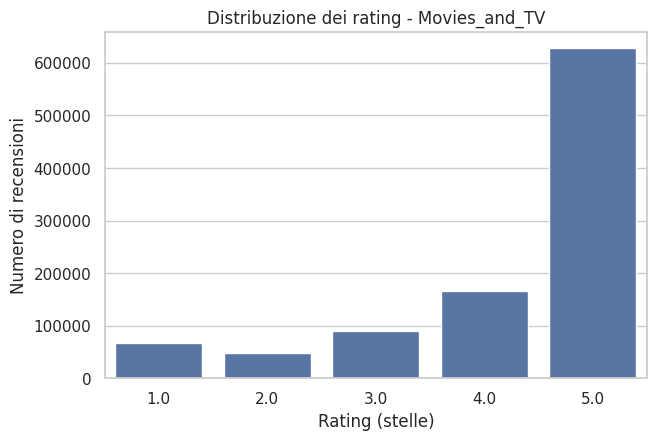

4-5 stelle: 793,571 (79.6%) | 3 stelle: 89,144 (8.9%) | 1-2 stelle: 114,691 (11.5%)


{'pos_4_5': 793571, 'neutro_3': 89144, 'neg_1_2': 114691}

In [5]:
n_rec = len(df)
n_users = df[ID_UTENTE].nunique()
n_items = df[ID_ITEM].nunique()
densita = n_rec / (n_users * n_items)

print("=== PANORAMICA (dati grezzi) ===")
print(f"Recensioni: {n_rec:,} | Utenti: {n_users:,} | Prodotti: {n_items:,}")
print(f"Densita matrice utente-item: {densita*100:.6f}%")
print(f"Rating medi per utente: {n_rec/n_users:.2f} | per prodotto: {n_rec/n_items:.2f}")

salva_risultato("eda_utenti", n_users)
salva_risultato("eda_prodotti", n_items)
salva_risultato("eda_densita_pct", round(densita*100, 6))
salva_risultato("eda_rating_per_utente", round(n_rec/n_users, 2))
salva_risultato("eda_rating_per_prodotto", round(n_rec/n_items, 2))

# Distribuzione dei rating
plt.figure(figsize=(7, 4.5))
ax = sns.countplot(x="rating", data=df, color="#4C72B0", order=[1.0, 2.0, 3.0, 4.0, 5.0])
ax.set_title(f"Distribuzione dei rating - {CATEGORY}")
ax.set_xlabel("Rating (stelle)"); ax.set_ylabel("Numero di recensioni")
salva_fig("fig_01_distribuzione_rating.png"); plt.show()

# Quote per fascia, le stesse tre classi usate nella Parte 3
q_pos = int((df["rating"] >= 4).sum()); q_neu = int((df["rating"] == 3).sum()); q_neg = int((df["rating"] <= 2).sum())
print(f"4-5 stelle: {q_pos:,} ({q_pos/n_rec*100:.1f}%) | 3 stelle: {q_neu:,} ({q_neu/n_rec*100:.1f}%) "
      f"| 1-2 stelle: {q_neg:,} ({q_neg/n_rec*100:.1f}%)")
salva_risultato("eda_quote_dedup", {"pos_4_5": q_pos, "neutro_3": q_neu, "neg_1_2": q_neg})

[figura] ./report/figure/fig_02_longtail.png


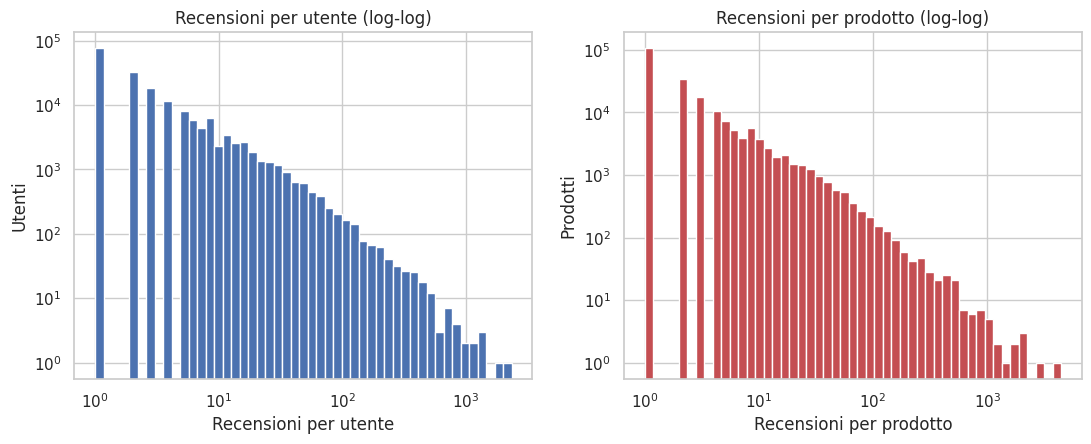

Utenti con 1 sola recensione: 41.6%
Prodotti con 1 sola recensione: 51.1%


In [6]:
# Coda lunga: recensioni per utente e per prodotto (scala log-log)
rec_utente = df[ID_UTENTE].value_counts()
rec_prodotto = df[ID_ITEM].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(rec_utente.values, bins=np.logspace(0, np.log10(rec_utente.max()), 50), color="#4C72B0")
axes[0].set(xscale="log", yscale="log", title="Recensioni per utente (log-log)",
            xlabel="Recensioni per utente", ylabel="Utenti")
axes[1].hist(rec_prodotto.values, bins=np.logspace(0, np.log10(rec_prodotto.max()), 50), color="#C44E52")
axes[1].set(xscale="log", yscale="log", title="Recensioni per prodotto (log-log)",
            xlabel="Recensioni per prodotto", ylabel="Prodotti")
salva_fig("fig_02_longtail.png"); plt.show()

pct_u1 = float((rec_utente == 1).mean()*100)
pct_p1 = float((rec_prodotto == 1).mean()*100)
print(f"Utenti con 1 sola recensione: {pct_u1:.1f}%")
print(f"Prodotti con 1 sola recensione: {pct_p1:.1f}%")
salva_risultato("eda_utenti_1_recensione_pct", round(pct_u1, 1))
salva_risultato("eda_prodotti_1_recensione_pct", round(pct_p1, 1))
libera("rec_utente", "rec_prodotto")

Matrice di correlazione:


,rating,helpful_vote,verified_purchase
rating,1.0000,-0.0402,0.1179
helpful_vote,-0.0402,1.0000,-0.0679
verified_purchase,0.1179,-0.0679,1.0000


[figura] ./report/figure/fig_03_correlazioni.png


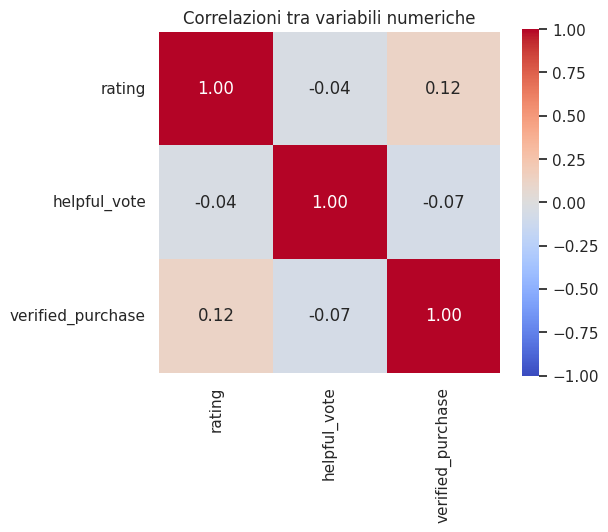


Statistiche di helpful_vote:


,count,mean,std,min,25%,50%,75%,max
helpful_vote,997406.0,1.141,10.369,0.0,0.0,0.0,0.0,2162.0


In [7]:
# Correlazioni tra le tre variabili numeriche del file delle recensioni:
# voto, voti utili ricevuti dalla recensione, acquisto verificato (0/1).
num = df[["rating", "helpful_vote", "verified_int"]].rename(columns={"verified_int": "verified_purchase"})
corr = num.corr()
print("Matrice di correlazione:")
display(corr.round(4))

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlazioni tra variabili numeriche")
salva_fig("fig_03_correlazioni.png"); plt.show()
corr.round(4).to_csv(os.path.join(FIG_DIR, "tab_01_correlazioni.csv"))

salva_risultato("eda_corr_rating_helpful", round(float(corr.loc["rating", "helpful_vote"]), 4))
salva_risultato("eda_corr_rating_verified", round(float(corr.loc["rating", "verified_purchase"]), 4))
salva_risultato("eda_corr_helpful_verified", round(float(corr.loc["helpful_vote", "verified_purchase"]), 4))
print("\nStatistiche di helpful_vote:")
display(df["helpful_vote"].describe().round(3).to_frame().T)
libera("num", "corr")

## 1.3 — Filtro k-core
Applico un **k-core iterativo**: elimino utenti e prodotti con meno di `k` rating e ripeto
finche la matrice non e stabile. Confronto k = 3/5/10/20 e adotto la soglia `K_CORE`.

k= 3 -> utenti= 66,092 prodotti= 61,435 rating= 669,857 densita=0.0165%
k= 5 -> utenti= 33,698 prodotti= 30,923 rating= 463,509 densita=0.0445%
k=10 -> utenti=  7,326 prodotti=  6,773 rating= 146,795 densita=0.2958%
k=20 -> utenti=      0 prodotti=      0 rating=       0 densita=0.0000%


,k,utenti,prodotti,rating,%_rating,densita_%
0,3,66092,61435,669857,67.16,0.0165
1,5,33698,30923,463509,46.47,0.0445
2,10,7326,6773,146795,14.72,0.2958
3,20,0,0,0,0.00,0.0000


[tabella] ./report/figure/tab_02_kcore.csv
[figura] ./report/figure/fig_04_kcore.png


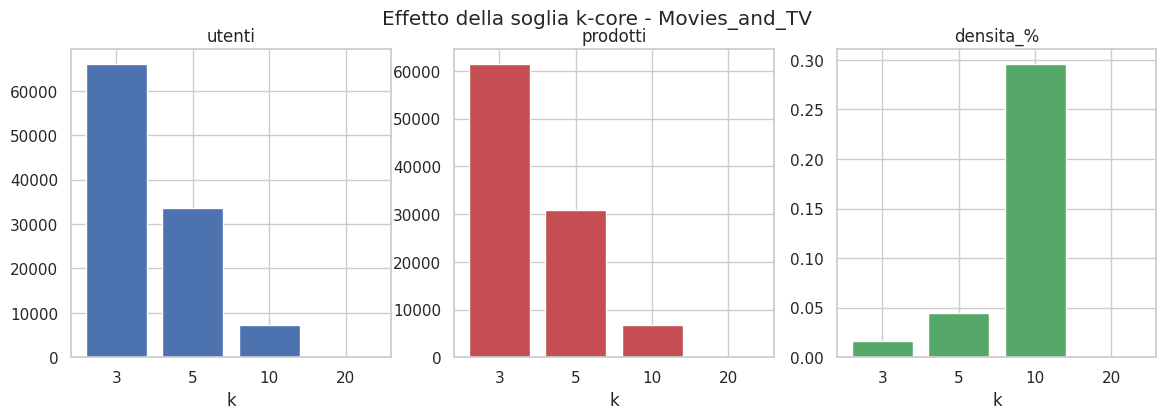

In [8]:
def kcore_iterativo(dati, k, uc=ID_UTENTE, ic=ID_ITEM):
    """Tiene solo utenti e prodotti con almeno k rating, iterando finche la matrice e stabile."""
    d = dati[[uc, ic, "rating"]].copy()
    while True:
        n0 = len(d)
        cu = d[uc].value_counts(); ci = d[ic].value_counts()
        d = d[d[uc].isin(cu[cu >= k].index) & d[ic].isin(ci[ci >= k].index)]
        if len(d) == n0:
            break
    return d

righe = []
for k in [3, 5, 10, 20]:
    d = kcore_iterativo(df, k)
    nu, ni, nr = d[ID_UTENTE].nunique(), d[ID_ITEM].nunique(), len(d)
    dens = nr / (nu * ni) if nu and ni else 0
    righe.append({"k": k, "utenti": nu, "prodotti": ni, "rating": nr,
                  "%_rating": round(nr/n_rec*100, 2), "densita_%": round(dens*100, 4)})
    print(f"k={k:2d} -> utenti={nu:>7,} prodotti={ni:>7,} rating={nr:>8,} densita={dens*100:.4f}%")
    del d
gc.collect()

tab_kcore = pd.DataFrame(righe)
display(tab_kcore); salva_tab(tab_kcore, "tab_02_kcore.csv")
salva_risultato("kcore_confronto", tab_kcore.to_dict("records"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, colore in zip(axes, ["utenti", "prodotti", "densita_%"], ["#4C72B0", "#C44E52", "#55A868"]):
    ax.bar(tab_kcore["k"].astype(str), tab_kcore[col], color=colore)
    ax.set_title(col); ax.set_xlabel("k")
fig.suptitle(f"Effetto della soglia k-core - {CATEGORY}")
salva_fig("fig_04_kcore.png"); plt.show()

In [9]:
print(f"Applico k-core = {K_CORE}...")
path_core      = os.path.join(DATA_DIR, f"{CATEGORY}_kcore{K_CORE}.parquet")
path_core_full = os.path.join(DATA_DIR, f"{CATEGORY}_kcore{K_CORE}_full.parquet")

# --- k-core COMPLETO (senza tetti): e il dataset del test 8.2 ---
df_core_full = kcore_iterativo(df, K_CORE).reset_index(drop=True)
nu, ni, nr = df_core_full[ID_UTENTE].nunique(), df_core_full[ID_ITEM].nunique(), len(df_core_full)
print(f"Dataset k-core: {nr:,} rating | {nu:,} utenti | {ni:,} prodotti | densita {nr/(nu*ni)*100:.4f}%")
df_core_full.to_parquet(path_core_full, index=False)
salva_risultato("kcore_full", {"rating": nr, "utenti": nu, "prodotti": ni,
                               "densita_pct": round(nr/(nu*ni)*100, 4)})

# --- Tetti dimensionali ---
# Il K-NN di Surprise costruisce matrici di similarita che crescono col QUADRATO del numero
# di utenti (user-based) e di prodotti (item-based): senza tetti la item-item satura la RAM.
df_core = df_core_full.copy()

if df_core[ID_UTENTE].nunique() > USERS_CAP:
    print(f"[!] {df_core[ID_UTENTE].nunique():,} utenti: tengo i {USERS_CAP:,} piu attivi.")
    top_users = df_core[ID_UTENTE].value_counts().head(USERS_CAP).index
    df_core = df_core[df_core[ID_UTENTE].isin(top_users)].reset_index(drop=True)
    df_core = kcore_iterativo(df_core, K_CORE).reset_index(drop=True)

if df_core[ID_ITEM].nunique() > ITEMS_CAP:
    print(f"[!] {df_core[ID_ITEM].nunique():,} prodotti: tengo i {ITEMS_CAP:,} piu recensiti.")
    top_items = df_core[ID_ITEM].value_counts().head(ITEMS_CAP).index
    df_core = df_core[df_core[ID_ITEM].isin(top_items)].reset_index(drop=True)
    df_core = kcore_iterativo(df_core, K_CORE).reset_index(drop=True)

nu, ni, nr = df_core[ID_UTENTE].nunique(), df_core[ID_ITEM].nunique(), len(df_core)
print(f"Dataset finale: {nr:,} rating | {nu:,} utenti | {ni:,} prodotti | densita {nr/(nu*ni)*100:.4f}%")
df_core.to_parquet(path_core, index=False)
salva_risultato("dataset_finale", {"rating": nr, "utenti": nu, "prodotti": ni,
                                   "densita_pct": round(nr/(nu*ni)*100, 4)})

# Il k-core completo resta su parquet e viene ricaricato dal cap. 8.2: lo tolgo dalla RAM.
libera("df_core_full", "top_users", "top_items")

Applico k-core = 5...
Dataset k-core: 463,509 rating | 33,698 utenti | 30,923 prodotti | densita 0.0445%
[!] 33,698 utenti: tengo i 4,000 piu attivi.
[!] 14,594 prodotti: tengo i 12,500 piu recensiti.
Dataset finale: 141,863 rating | 4,000 utenti | 12,500 prodotti | densita 0.2837%


## 1.4 — Conversione al formato Surprise

In [10]:
from surprise import Dataset, Reader, KNNBasic, SVD, accuracy
from surprise import model_selection
from surprise.model_selection import cross_validate, GridSearchCV

reader = Reader(rating_scale=(1, 5))
dati_surprise = Dataset.load_from_df(df_core[[ID_UTENTE, ID_ITEM, "rating"]], reader)
print(f"Dataset Surprise pronto: {len(df_core):,} rating.")

Dataset Surprise pronto: 141,863 rating.


## 1.5 — K-NN: elbow + grid search
Come nel Lab 8: prima l'elbow method sul numero di vicini, poi una grid search su similarita
(cosine/pearson/msd), approccio user/item-based e k. Valutazione con MSE e RMSE in 5-fold CV.

  KNNBasic k=10: RMSE=1.1669
  KNNBasic k=20: RMSE=1.1665
  KNNBasic k=30: RMSE=1.1686
  KNNBasic k=40: RMSE=1.1677
  KNNBasic k=50: RMSE=1.1686
[figura] ./report/figure/fig_05_knn_elbow.png


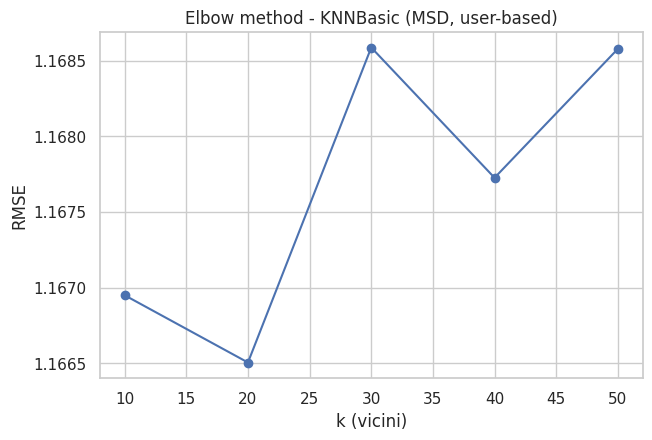

{10: 1.1669, 20: 1.1665, 30: 1.1686, 40: 1.1677, 50: 1.1686}

In [11]:
# Elbow method (KNNBasic di default = MSD, user-based)
ks = np.arange(10, 51, 10)
rmse_over_k = []
for k in ks:
    r = cross_validate(KNNBasic(k=int(k), verbose=False), dati_surprise, cv=CV_FOLDS,
                       measures=["rmse"], verbose=False, n_jobs=1)
    rmse_over_k.append(float(r["test_rmse"].mean()))
    print(f"  KNNBasic k={k}: RMSE={rmse_over_k[-1]:.4f}")

plt.figure(figsize=(7, 4.5))
plt.plot(ks, rmse_over_k, marker="o")
plt.title("Elbow method - KNNBasic (MSD, user-based)"); plt.xlabel("k (vicini)"); plt.ylabel("RMSE")
salva_fig("fig_05_knn_elbow.png"); plt.show()

salva_risultato("knn_elbow", {int(k): round(v, 4) for k, v in zip(ks, rmse_over_k)})

In [12]:
# Grid search K-NN: similarita x user/item x k
# verbose=False nella griglia evita che Surprise stampi una riga per ogni matrice di
# similarita calcolata (90 fit = 180 righe di log che rendono illeggibile l'output).
param_grid_knn = {
    "k": [20, 30, 40],
    "sim_options": {"name": ["msd", "cosine", "pearson"], "user_based": [True, False]},
    "verbose": [False],
}
print(f"Grid search K-NN: {3*3*2} configurazioni x {CV_FOLDS} fold (richiede tempo)...")
t0 = time.time()
gs_knn = GridSearchCV(KNNBasic, param_grid_knn, measures=["rmse", "mse"], cv=CV_FOLDS, n_jobs=1)
gs_knn.fit(dati_surprise)
print(f"Fatto in {(time.time()-t0)/60:.1f} min")

knn_best_params = {k: v for k, v in gs_knn.best_params["rmse"].items() if k != "verbose"}
print(f"Best RMSE K-NN: {gs_knn.best_score['rmse']:.4f} | MSE: {gs_knn.best_score['mse']:.4f}")
print(f"Configurazione ottimale: {knn_best_params}")
pd.DataFrame(gs_knn.cv_results).to_csv(os.path.join(FIG_DIR, "tab_03_knn_grid.csv"), index=False)

salva_risultato("knn_best", {"rmse": round(float(gs_knn.best_score["rmse"]), 4),
                             "mse":  round(float(gs_knn.best_score["mse"]), 4),
                             "params": knn_best_params})

Grid search K-NN: 18 configurazioni x 5 fold (richiede tempo)...
Fatto in 8.2 min
Best RMSE K-NN: 1.0630 | MSE: 1.1299
Configurazione ottimale: {'k': 40, 'sim_options': {'name': 'cosine', 'user_based': False}}


{'rmse': 1.063,
 'mse': 1.1299,
 'params': {'k': 40, 'sim_options': {'name': 'cosine', 'user_based': False}}}

## 1.6 — SVD (Matrix Factorization) + grid search

In [13]:
# random_state nella griglia: l'SVD di Surprise inizializza i fattori a caso e senza seed
# esplicito usa il RNG globale, quindi lo stesso notebook darebbe RMSE diversi a ogni run.
param_grid_svd = {"n_factors": [50, 100], "n_epochs": [20], "lr_all": [0.005],
                  "reg_all": [0.02, 0.05], "random_state": [RANDOM_STATE]}
print("Grid search SVD...")
t0 = time.time()
gs_svd = GridSearchCV(SVD, param_grid_svd, measures=["rmse", "mse"], cv=CV_FOLDS, n_jobs=2)
gs_svd.fit(dati_surprise)
print(f"Fatto in {(time.time()-t0)/60:.1f} min")

svd_best_params = dict(gs_svd.best_params["rmse"])
print(f"Best RMSE SVD: {gs_svd.best_score['rmse']:.4f} | MSE: {gs_svd.best_score['mse']:.4f}")
print(f"Configurazione ottimale: {svd_best_params}")
pd.DataFrame(gs_svd.cv_results).to_csv(os.path.join(FIG_DIR, "tab_04_svd_grid.csv"), index=False)

salva_risultato("svd_best", {"rmse": round(float(gs_svd.best_score["rmse"]), 4),
                             "mse":  round(float(gs_svd.best_score["mse"]), 4),
                             "params": svd_best_params})

Grid search SVD...
Fatto in 0.4 min
Best RMSE SVD: 0.9401 | MSE: 0.8838
Configurazione ottimale: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.05, 'random_state': 42}


{'rmse': 0.9401,
 'mse': 0.8838,
 'params': {'n_factors': 50,
  'n_epochs': 20,
  'lr_all': 0.005,
  'reg_all': 0.05,
  'random_state': 42}}

## 1.7 — Confronto K-NN vs SVD

,modello,RMSE,MSE,config
0,SVD,0.9401,0.8838,"{'n_factors': 50, 'n_epochs': 20, 'lr_all': 0...."
1,K-NN (KNNBasic),1.0630,1.1299,"{'k': 40, 'sim_options': {'name': 'cosine', 'u..."


[tabella] ./report/figure/tab_05_confronto_modelli.csv
[figura] ./report/figure/fig_06_confronto_modelli.png


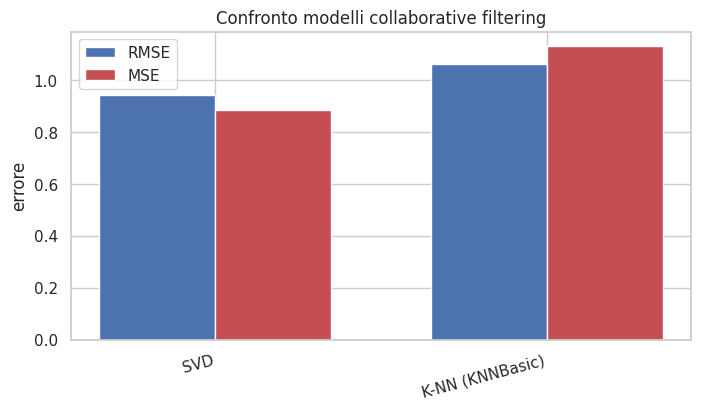

>>> Modello migliore (RMSE piu basso): SVD
>>> Riduzione dell'errore rispetto all'altro modello: 11.6%


11.6

In [14]:
# Confronto dei modelli di collaborative filtering provati
modelli_cf = {
    "K-NN (KNNBasic)": (gs_knn, KNNBasic),
    "SVD":             (gs_svd, SVD),
}
righe = []
for nome, (gs, _cls) in modelli_cf.items():
    cfg = {k: v for k, v in gs.best_params["rmse"].items() if k != "verbose"}
    righe.append({"modello": nome, "RMSE": round(float(gs.best_score["rmse"]), 4),
                  "MSE": round(float(gs.best_score["mse"]), 4), "config": str(cfg)})
confronto = pd.DataFrame(righe).sort_values("RMSE").reset_index(drop=True)
display(confronto)
salva_tab(confronto[["modello", "RMSE", "MSE"]], "tab_05_confronto_modelli.csv")

plt.figure(figsize=(8, 4)); x = np.arange(len(confronto)); w = 0.35
plt.bar(x - w/2, confronto["RMSE"], w, label="RMSE", color="#4C72B0")
plt.bar(x + w/2, confronto["MSE"],  w, label="MSE",  color="#C44E52")
plt.xticks(x, confronto["modello"], rotation=15, ha="right"); plt.ylabel("errore"); plt.legend()
plt.title("Confronto modelli collaborative filtering")
salva_fig("fig_06_confronto_modelli.png"); plt.show()

nome_migliore = confronto.iloc[0]["modello"]
gs_migliore, classe_migliore = modelli_cf[nome_migliore]
guadagno = (confronto.iloc[1]["RMSE"] - confronto.iloc[0]["RMSE"]) / confronto.iloc[1]["RMSE"] * 100
print(f">>> Modello migliore (RMSE piu basso): {nome_migliore}")
print(f">>> Riduzione dell'errore rispetto all'altro modello: {guadagno:.1f}%")
salva_risultato("cf_migliore", nome_migliore)
salva_risultato("cf_guadagno_pct", round(float(guadagno), 1))

## 1.8 — Filling della matrice con la configurazione ottimale

In [15]:
trainset = dati_surprise.build_full_trainset()

# Alleno il modello vincente (qualunque sia) sull'intero trainset
algo_final = classe_migliore(**gs_migliore.best_params["rmse"])
print(f"Alleno il modello migliore ({nome_migliore}) sull'intero trainset...")
algo_final.fit(trainset)

users_id = df_core[ID_UTENTE].unique()
items_id = df_core[ID_ITEM].unique()
gia_visti = df_core.groupby(ID_UTENTE)[ID_ITEM].apply(set).to_dict()
print(f"Utenti: {len(users_id):,} | Prodotti: {len(items_id):,} | "
      f"celle della matrice: {len(users_id)*len(items_id):,} di cui {len(df_core):,} osservate")

Alleno il modello migliore (SVD) sull'intero trainset...
Utenti: 4,000 | Prodotti: 12,500 | celle della matrice: 50,000,000 di cui 141,863 osservate


## 1.8b - Filling della matrice: K-NN (passo 3) e Matrix Factorization (passo 6)
Il passo 3 della traccia chiede il filling della matrice con la configurazione ottimale del K-NN,
e il passo 6 di rifarlo con la matrix factorization e confrontare i due risultati. Qui eseguo
entrambi i riempimenti sullo **stesso campione di utenti**, cosi le due matrici sono confrontabili
cella per cella, e li salvo su file. Il confronto in MSE/RMSE e quello validato in 5-fold CV nelle
celle 1.5 e 1.6; le raccomandazioni del 1.9 e la segmentazione del 1.10 usano il riempimento del
modello migliore.

In [16]:
# ================= Filling della matrice: K-NN (passo 3) e SVD (passo 6) =================
# La traccia chiede il filling con la configurazione ottimale del K-NN (passo 3) e poi lo
# stesso riempimento via matrix factorization, con confronto in MSE/RMSE (passo 6).
# La matrice intera e 4.000 x 12.500 = 50 milioni di celle: materializzarla due volte non
# sta nella RAM di Colab, quindi la riempio per un campione casuale di UTENTI_FILL utenti.
# Il campione e lo STESSO per i due modelli, cosi il confronto e cella per cella.
knn_ottimo = KNNBasic(**gs_knn.best_params["rmse"])
knn_ottimo.fit(trainset)
svd_ottimo = SVD(**gs_svd.best_params["rmse"])
svd_ottimo.fit(trainset)

rng_fill = np.random.default_rng(RANDOM_STATE)
utenti_fill = rng_fill.choice(users_id, size=min(UTENTI_FILL, len(users_id)), replace=False)

coppie_u, coppie_i = [], []
for uid in utenti_fill:
    visti = gia_visti.get(uid, set())
    for iid in items_id:
        if iid not in visti:
            coppie_u.append(uid); coppie_i.append(iid)
print(f"Celle da stimare: {len(coppie_u):,} ({len(utenti_fill)} utenti x ~{len(items_id):,} prodotti)")

t0 = time.time()
pred_knn = np.fromiter((knn_ottimo.predict(u, i).est for u, i in zip(coppie_u, coppie_i)),
                       dtype="float32", count=len(coppie_u))
print(f"  filling K-NN in {(time.time()-t0)/60:.1f} min")
t0 = time.time()
pred_svd = np.fromiter((svd_ottimo.predict(u, i).est for u, i in zip(coppie_u, coppie_i)),
                       dtype="float32", count=len(coppie_u))
print(f"  filling SVD in {(time.time()-t0)/60:.1f} min")

fill = pd.DataFrame({ID_UTENTE: coppie_u, ID_ITEM: coppie_i,
                     "rating_predetto_knn": pred_knn, "rating_predetto_svd": pred_svd})
fill.to_parquet(os.path.join(RES_DIR, "filling_matrice.parquet"), index=False)
fill.head(1000).to_csv(os.path.join(RES_DIR, "filling_matrice_anteprima.csv"), index=False)
display(fill.head(5))

# I due riempimenti si differenziano solo per il modello che genera i valori mancanti:
# le statistiche mostrano quanto diversamente i due modelli "vedono" le celle vuote.
print(f"\nK-NN -> media {pred_knn.mean():.3f}  dev.std {pred_knn.std():.3f}  "
      f"valori distinti {len(np.unique(pred_knn)):,}")
print(f"SVD  -> media {pred_svd.mean():.3f}  dev.std {pred_svd.std():.3f}  "
      f"valori distinti {len(np.unique(pred_svd)):,}")

# Confronto dei due riempimenti (passo 6 della traccia): stessa matrice, modelli diversi.
# Le metriche sono quelle validate in 5-fold CV nelle celle 1.5 e 1.6.
confronto_filling = pd.DataFrame([
    {"Filling": "K-NN (configurazione ottimale)", "RMSE": round(float(gs_knn.best_score["rmse"]), 4),
     "MSE": round(float(gs_knn.best_score["mse"]), 4)},
    {"Filling": "Matrix Factorization (SVD)",     "RMSE": round(float(gs_svd.best_score["rmse"]), 4),
     "MSE": round(float(gs_svd.best_score["mse"]), 4)},
])
display(confronto_filling); salva_tab(confronto_filling, "tab_04b_confronto_filling.csv")
salva_risultato("filling", {"celle_stimate": len(coppie_u), "utenti": int(len(utenti_fill)),
                            "knn_media": round(float(pred_knn.mean()), 3),
                            "svd_media": round(float(pred_svd.mean()), 3)})
print(">>> Il filling usato per le raccomandazioni e la segmentazione e' quello di:", nome_migliore)
libera("coppie_u", "coppie_i", "pred_knn", "pred_svd", "fill", "knn_ottimo", "svd_ottimo")

Celle da stimare: 2,493,173 (200 utenti x ~12,500 prodotti)
  filling K-NN in 1.0 min
  filling SVD in 0.2 min


,user_id,item_id,rating_predetto_knn,rating_predetto_svd
0,AGMNSCEH2XSWA2EZFDIAIITRSO7Q,B00000IQVC,4.223307,3.328678
1,AGMNSCEH2XSWA2EZFDIAIITRSO7Q,B00001QGUM,4.223307,3.315416
2,AGMNSCEH2XSWA2EZFDIAIITRSO7Q,6305350221,4.223307,3.537761
3,AGMNSCEH2XSWA2EZFDIAIITRSO7Q,B00000K19E,4.223307,4.040267
4,AGMNSCEH2XSWA2EZFDIAIITRSO7Q,6305692696,4.223307,3.899411



K-NN -> media 4.288  dev.std 0.707  valori distinti 137,097
SVD  -> media 4.296  dev.std 0.546  valori distinti 1,744,633


,Filling,RMSE,MSE
0,K-NN (configurazione ottimale),1.0630,1.1299
1,Matrix Factorization (SVD),0.9401,0.8838


[tabella] ./report/figure/tab_04b_confronto_filling.csv
>>> Il filling usato per le raccomandazioni e la segmentazione e' quello di: SVD


## 1.9 — Liste Top-N per utente
Per ogni utente genero la lista dei top-N prodotti consigliati a partire dai rating predetti,
escludendo i prodotti che ha gia valutato.

In [17]:
# RNG dedicato e seminato: le liste top-N sono cosi riproducibili a ogni esecuzione.
rng_topn = np.random.default_rng(RANDOM_STATE)
utenti_target = (users_id if not MAX_UTENTI_TOPN else
                 rng_topn.choice(users_id, size=min(MAX_UTENTI_TOPN, len(users_id)), replace=False))

print(f"Calcolo top-{TOP_N} per {len(utenti_target):,} utenti...")
t0 = time.time()
righe_topn = []
for n_fatti, uid in enumerate(utenti_target, 1):
    visti = gia_visti.get(uid, set())
    candidati = [i for i in items_id if i not in visti]
    if len(candidati) > MAX_CANDIDATI:
        candidati = list(rng_topn.choice(candidati, MAX_CANDIDATI, replace=False))
    # Ordino sulle stime NON troncate (clip=False): col clip a [1,5] gli utenti generosi
    # avrebbero decine di film a 5.00 esatti e la classifica tra loro sarebbe arbitraria.
    punteggi = [(i, algo_final.predict(uid, i, clip=False).est) for i in candidati]
    punteggi.sort(key=lambda x: x[1], reverse=True)
    for rank, (i, s) in enumerate(punteggi[:TOP_N], 1):
        righe_topn.append({"user_id": uid, "rank": rank, "item_id": i, "score": round(s, 3)})
    if n_fatti % 500 == 0:
        print(f"  {n_fatti}/{len(utenti_target)}")

top_n_df = pd.DataFrame(righe_topn)
top_n_df.to_csv(os.path.join(RES_DIR, "top_N_recommendations.csv"), index=False)
print(f"Salvate {len(top_n_df):,} raccomandazioni in {(time.time()-t0)/60:.1f} min.")

# Controllo che le liste non siano classifiche di pari merito (motivo del clip=False)
punteggi_unici = top_n_df.groupby("user_id")["score"].nunique()
print(f"Utenti con {TOP_N} punteggi tutti distinti: "
      f"{(punteggi_unici == TOP_N).mean()*100:.1f}%")
salva_risultato("topn", {"utenti": int(len(utenti_target)), "raccomandazioni": int(len(top_n_df)),
                         "pct_liste_senza_pari_merito": round(float((punteggi_unici == TOP_N).mean()*100), 1)})
display(top_n_df.head(12))
libera("righe_topn", "punteggi_unici")

Calcolo top-10 per 2,000 utenti...
  500/2000
  1000/2000
  1500/2000
  2000/2000
Salvate 20,000 raccomandazioni in 1.1 min.
Utenti con 10 punteggi tutti distinti: 66.6%


,user_id,rank,item_id,score
0,AEMV4AQMTRHICJECLPLTC6SV6D3A,1,B0001DMVBC,5.396
1,AEMV4AQMTRHICJECLPLTC6SV6D3A,2,B001M432XA,5.337
2,AEMV4AQMTRHICJECLPLTC6SV6D3A,3,B000067DNF,5.318
3,AEMV4AQMTRHICJECLPLTC6SV6D3A,4,B003ZUTVJS,5.301
4,AEMV4AQMTRHICJECLPLTC6SV6D3A,5,B07KFRF1X5,5.294
5,AEMV4AQMTRHICJECLPLTC6SV6D3A,6,B00APE1NZW,5.275
6,AEMV4AQMTRHICJECLPLTC6SV6D3A,7,B003UESJH4,5.261
7,AEMV4AQMTRHICJECLPLTC6SV6D3A,8,B09CG371PV,5.259
8,AEMV4AQMTRHICJECLPLTC6SV6D3A,9,B00003CXC5,5.256
9,AEMV4AQMTRHICJECLPLTC6SV6D3A,10,B01AIW6KZS,5.246


## 1.10 — Segmentazione utenti con K-Means + scelta di k
Segmento gli utenti con K-Means sul profilo di rating ricostruito dal modello (normalizzato L2,
quindi il clustering lavora di fatto in similarita coseno). Il numero di cluster non lo fisso a
priori: lo scelgo con **Elbow (inertia)** e **Silhouette** come nel Lab 7, prendendo il k con
silhouette piu alto.

Matrice dei profili ricostruiti: (4000, 12500) (200 MB)
k=2: inertia=537.0  silhouette=0.7850
k=3: inertia=479.4  silhouette=0.7243
k=4: inertia=456.7  silhouette=0.6608
k=5: inertia=445.7  silhouette=0.6253
k=6: inertia=438.8  silhouette=0.6116
k=7: inertia=432.9  silhouette=0.6063
k=8: inertia=427.7  silhouette=0.5834
[figura] ./report/figure/fig_07a_scelta_k.png


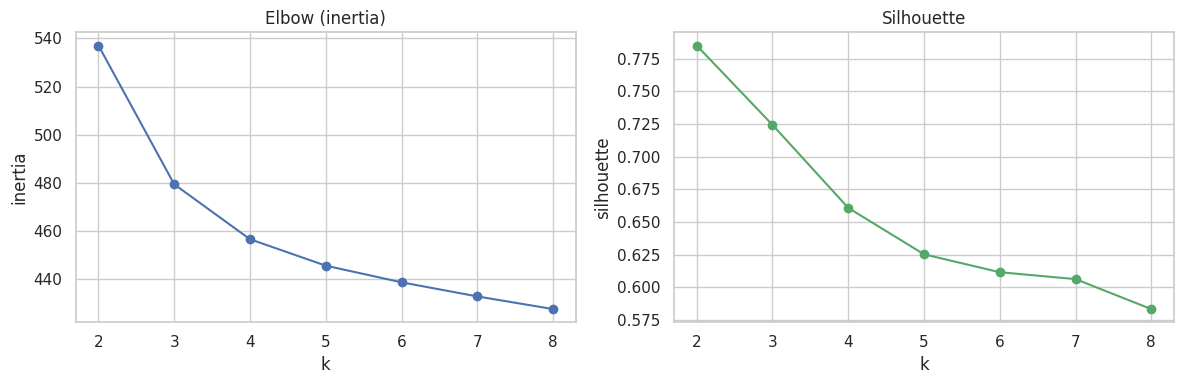

>>> Numero di cluster scelto (silhouette massimo): 2 (silhouette 0.785)
Utenti per cluster:
0    1718
1    2282
Name: count, dtype: int64
[figura] ./report/figure/fig_07_kmeans.png


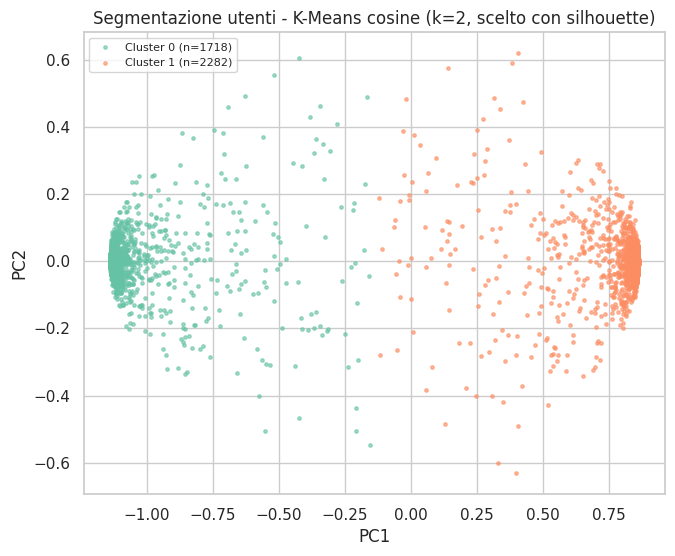

,cluster,n_utenti,n_rating,rating_medio
0,0,1718,64819,3.691
1,1,2282,77044,4.672


[tabella] ./report/figure/tab_06_kmeans_cluster.csv


In [18]:
# === Segmentazione utenti con K-Means: scelta di k con Elbow + Silhouette (Lab 7) ===
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.sparse import csr_matrix

# Rappresento ogni utente col suo PROFILO DI RATING ricostruito dal modello (il "fill"):
# cosi il clustering riflette i gusti/generosita reali e i gruppi risultano piu separati
# (clusterizzare sui soli fattori latenti "nudi" dava cluster poco distinti).
# float32: la matrice e 4.000 x 12.500, in float64 pesa 400 MB e la PCA ne fa una copia.
if hasattr(algo_final, "pu") and hasattr(algo_final, "qi"):
    mu = trainset.global_mean
    # matrice ricostruita utenti x item = mu + bias_utente + bias_item + fattori_utente . fattori_item^T
    R_hat = (mu + algo_final.bu[:, None] + algo_final.bi[None, :]
             + algo_final.pu @ algo_final.qi.T).astype("float32")
    inner_to_raw = {inner: raw for raw, inner in trainset._raw2inner_id_users.items()}
    raw_user_order = [inner_to_raw[i] for i in range(R_hat.shape[0])]
else:
    # fallback (se vincesse un K-NN): matrice osservata dei rating
    u_idx = {u: i for i, u in enumerate(users_id)}
    i_idx = {p: i for i, p in enumerate(items_id)}
    R_hat = csr_matrix((df_core["rating"].values.astype("float32"),
                        (df_core[ID_UTENTE].map(u_idx).values, df_core[ID_ITEM].map(i_idx).values)),
                       shape=(len(users_id), len(items_id))).toarray()
    raw_user_order = list(users_id)
print("Matrice dei profili ricostruiti:", R_hat.shape, f"({R_hat.nbytes/1e6:.0f} MB)")

# Riduzione dimensionale (PCA a 20 componenti) + normalizzazione L2 => K-Means per similarita coseno
X_red = PCA(n_components=20, svd_solver="randomized",
            random_state=RANDOM_STATE).fit_transform(R_hat)
libera("R_hat")
U_norm = normalize(X_red, norm="l2", axis=1)

# --- Scelta del numero di cluster k con Elbow (inertia) + Silhouette (Lab 7) ---
ks = range(2, 9)
inertie, silhouette = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(U_norm)
    inertie.append(float(km.inertia_))
    silhouette.append(float(silhouette_score(U_norm, km.labels_)))
    print(f"k={k}: inertia={km.inertia_:.1f}  silhouette={silhouette[-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inertie, marker="o"); ax[0].set(title="Elbow (inertia)", xlabel="k", ylabel="inertia")
ax[1].plot(list(ks), silhouette, marker="o", color="#55A868"); ax[1].set(title="Silhouette", xlabel="k", ylabel="silhouette")
plt.tight_layout(); salva_fig("fig_07a_scelta_k.png"); plt.show()

N_CLUSTERS = int(list(ks)[int(np.argmax(silhouette))])
sil_max = round(max(silhouette), 4)
print(f">>> Numero di cluster scelto (silhouette massimo): {N_CLUSTERS} (silhouette {sil_max})")
salva_risultato("kmeans_scelta_k", {"k": N_CLUSTERS, "silhouette": sil_max,
                                    "silhouette_per_k": {int(k): round(s, 4) for k, s in zip(ks, silhouette)}})

# --- Clustering finale e visualizzazione ---
etichette = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10).fit_predict(U_norm)
print("Utenti per cluster:")
print(pd.Series(etichette).value_counts().sort_index())

proj = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(U_norm)
plt.figure(figsize=(7.5, 6))
palette = sns.color_palette("Set2", N_CLUSTERS)
for c in range(N_CLUSTERS):
    m = etichette == c
    plt.scatter(proj[m, 0], proj[m, 1], s=6, alpha=0.6, color=palette[c], label=f"Cluster {c} (n={m.sum()})")
plt.title(f"Segmentazione utenti - K-Means cosine (k={N_CLUSTERS}, scelto con silhouette)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(fontsize=8)
salva_fig("fig_07_kmeans.png"); plt.show()

# Profilo dei cluster (rating medio e attivita) - interpretabile per il report
cluster_df = pd.DataFrame({ID_UTENTE: raw_user_order, "cluster": etichette})
stat_cluster = (df_core.merge(cluster_df, on=ID_UTENTE, how="inner")
                .groupby("cluster")
                .agg(n_utenti=(ID_UTENTE, "nunique"), n_rating=("rating", "size"),
                     rating_medio=("rating", "mean")).round(3).reset_index())
display(stat_cluster)
salva_tab(stat_cluster, "tab_06_kmeans_cluster.csv")
cluster_df.to_csv(os.path.join(RES_DIR, "utenti_cluster.csv"), index=False)
salva_risultato("kmeans_cluster", stat_cluster.to_dict("records"))
libera("X_red", "U_norm", "proj")

## 1.11 — Riepilogo Parte 1
Figure `fig_01`..`fig_07` e tabelle in `report/figure/`; liste top-N e cluster in
`report/risultati/`. Il dataset filtrato e salvato in `dataset/` e viene riusato dalla Parte 2.

# PARTE 2 - Content-Based Filtering (INTERMEDIO)

_Corrisponde al **capitolo 5** del report: metadati e preprocessing, embedding TF-IDF e DistilBERT, K-NN per utente sui contenuti, confronto CB vs CF sullo stesso split._

## 2.1 — Caricamento recensioni (k-core) e metadati
Riparto dal dataset filtrato della Parte 1 (se non c'e, lo ricostruisco dallo streaming). I
**metadati** (title, description) arrivano anch'essi da `hf://`: per evitare problemi di schema
sui campi annidati, leggo il file riga per riga tenendo solo i campi che servono.

In [19]:
# La Parte 2 riparte dal k-core salvato su parquet dalla Parte 1. Se il runtime si e
# riavviato basta rieseguire le celle 0, 0.1 e 0.2 e poi questa: non serve ri-scaricare.
from datasets import load_dataset

def kcore_iterativo(dati, k, uc=ID_UTENTE, ic=ID_ITEM):
    d = dati[[uc, ic, "rating"]].copy()
    while True:
        n0 = len(d)
        cu = d[uc].value_counts(); ci = d[ic].value_counts()
        d = d[d[uc].isin(cu[cu >= k].index) & d[ic].isin(ci[ci >= k].index)]
        if len(d) == n0:
            break
    return d

path_core = os.path.join(DATA_DIR, f"{CATEGORY}_kcore{K_CORE}.parquet")
if os.path.exists(path_core):
    df_core = pd.read_parquet(path_core)
    print("Caricato k-core dalla Parte 1:", df_core.shape)
else:
    print("k-core assente: ricostruisco dalle recensioni in streaming...")
    url = f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/{CATEGORY}.jsonl"
    ds = load_dataset("json", data_files=url, split="train", streaming=True).shuffle(seed=RANDOM_STATE, buffer_size=100000)
    righe = []
    for ex in ds:
        righe.append({"user_id": ex.get("user_id"), "parent_asin": ex.get("parent_asin"),
                      "asin": ex.get("asin"), "rating": ex.get("rating"),
                      "timestamp": ex.get("timestamp")})
        if len(righe) >= MAX_REVIEWS:
            break
    tmp = pd.DataFrame(righe)
    tmp["item_id"] = tmp["parent_asin"].fillna(tmp["asin"])
    tmp = tmp.dropna(subset=["user_id", "item_id", "rating"])
    tmp["rating"] = tmp["rating"].astype("float32")
    tmp = tmp.sort_values("timestamp").drop_duplicates(["user_id", "item_id"], keep="last")
    df_core = kcore_iterativo(tmp, K_CORE).reset_index(drop=True)
    if df_core[ID_UTENTE].nunique() > USERS_CAP:
        top_users = df_core[ID_UTENTE].value_counts().head(USERS_CAP).index
        df_core = kcore_iterativo(df_core[df_core[ID_UTENTE].isin(top_users)], K_CORE).reset_index(drop=True)
    if df_core[ID_ITEM].nunique() > ITEMS_CAP:
        top_items = df_core[ID_ITEM].value_counts().head(ITEMS_CAP).index
        df_core = kcore_iterativo(df_core[df_core[ID_ITEM].isin(top_items)], K_CORE).reset_index(drop=True)
    df_core.to_parquet(path_core, index=False)
    libera("tmp", "righe")
    print("Ricostruito:", df_core.shape)

# Serve la mappa item_id -> parent_asin per unire i metadati
if "parent_asin" not in df_core.columns:
    df_core["parent_asin"] = df_core[ID_ITEM]

print(f"{len(df_core):,} rating | {df_core[ID_UTENTE].nunique():,} utenti | {df_core[ID_ITEM].nunique():,} prodotti")

Caricato k-core dalla Parte 1: (141863, 3)
141,863 rating | 4,000 utenti | 12,500 prodotti


In [20]:
# I metadati NON si caricano con datasets/pyarrow: il campo annidato "details" ha schema
# incoerente (a volte lista, a volte stringa) e manda in errore l'inferenza dello schema.
# Soluzione: scarico il file e lo leggo riga per riga con json standard, tenendo solo
# parent_asin, title, description. Il risultato filtrato lo salvo su parquet: il file
# sorgente pesa diversi GB e senza cache un riavvio del runtime costringerebbe a
# ri-scaricarlo da capo.
import json
from huggingface_hub import hf_hub_download

item_target = set(df_core[ID_ITEM].unique())
path_meta_cache = os.path.join(DATA_DIR, f"meta_{CATEGORY}_filtrati.parquet")

def join_desc(x):
    if isinstance(x, (list, tuple)):
        return " ".join(map(str, x))
    return "" if x is None else str(x)

if os.path.exists(path_meta_cache):
    meta_core = pd.read_parquet(path_meta_cache)
    print("Metadati filtrati ricaricati dalla cache:", meta_core.shape)
else:
    print("Scarico i metadati (la prima volta puo richiedere qualche minuto)...")
    t0 = time.time()
    path_meta = hf_hub_download(
        repo_id="McAuley-Lab/Amazon-Reviews-2023",
        filename=f"raw/meta_categories/meta_{CATEGORY}.jsonl",
        repo_type="dataset",
    )
    righe_meta = []
    with open(path_meta, encoding="utf-8") as f:
        for line in f:
            try:
                ex = json.loads(line)
            except Exception:
                continue
            pid = ex.get("parent_asin")
            if pid in item_target:
                righe_meta.append({"item_id": pid,
                                   "title": ex.get("title") or "",
                                   "description": join_desc(ex.get("description"))})
    meta_core = pd.DataFrame(righe_meta).drop_duplicates("item_id")
    meta_core.to_parquet(path_meta_cache, index=False)
    print(f"Metadati letti e messi in cache in {(time.time()-t0)/60:.1f} min")
    libera("righe_meta")

meta_core["testo_prodotto"] = (meta_core["title"].astype(str) + ". " + meta_core["description"].astype(str)).str.strip()
meta_core = meta_core[meta_core["testo_prodotto"].str.len() > 0]
cov = meta_core["item_id"].nunique() / len(item_target) * 100
print(f"Prodotti con testo: {meta_core['item_id'].nunique():,}/{len(item_target):,} ({cov:.1f}%)")

# Allineo i rating ai soli item con testo, poi rifinisco il k-core
df_cb = df_core[df_core[ID_ITEM].isin(set(meta_core["item_id"]))].reset_index(drop=True)
df_cb = kcore_iterativo(df_cb, K_CORE).reset_index(drop=True)
meta_core = meta_core[meta_core["item_id"].isin(set(df_cb[ID_ITEM]))]
print(f"Dopo allineamento: {len(df_cb):,} rating | {df_cb[ID_UTENTE].nunique():,} utenti | {df_cb[ID_ITEM].nunique():,} prodotti")
salva_risultato("cb_dataset", {"copertura_testo_pct": round(float(cov), 1), "rating": len(df_cb),
                               "utenti": int(df_cb[ID_UTENTE].nunique()),
                               "prodotti": int(df_cb[ID_ITEM].nunique())})

Scarico i metadati (la prima volta puo richiedere qualche minuto)...


raw/meta_categories/meta_Movies_and_TV.j(…): reconstructing file:   0%|          |  0.00B / 1.29GB            

raw/meta_categories/meta_Movies_and_TV.j(…): downloading bytes:           |  0.00B            

Metadati letti e messi in cache in 0.3 min
Prodotti con testo: 12,500/12,500 (100.0%)
Dopo allineamento: 141,863 rating | 4,000 utenti | 12,500 prodotti


{'copertura_testo_pct': 100.0,
 'rating': 141863,
 'utenti': 4000,
 'prodotti': 12500}

## 2.2 — Preprocessing NLP (Lab 9)
Tokenizzazione, rimozione delle stopword e lemmatizzazione del testo title+description.

In [21]:
import nltk
for risorsa in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try: nltk.download(risorsa, quiet=True)
    except Exception as e: print("nltk:", risorsa, e)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
STOPWORD = set(stopwords.words("english")); lemm = WordNetLemmatizer()

def preprocessa(testo):
    tokens = word_tokenize(str(testo))
    tokens = [t for t in tokens if t.casefold() not in STOPWORD]
    tokens = [lemm.lemmatize(t.lower()) for t in tokens if t.isalpha() and len(t) > 2]
    return " ".join(tokens)

t0 = time.time()
meta_core = meta_core.copy()
meta_core["testo_pulito"] = meta_core["testo_prodotto"].apply(preprocessa)
print(f"Preprocessing di {len(meta_core):,} testi in {time.time()-t0:.0f}s")
display(meta_core[["title", "testo_pulito"]].head(3))

Preprocessing di 12,500 testi in 12s


,title,testo_pulito
0,Paddington,paddington based beloved novel featuring cast ...
1,"I, Frankenstein [DVD + Digital]",frankenstein dvd digital frankenstein creature...
2,Across the Line,across line investigating brutal killing borde...


## 2.3 — Embedding: TF-IDF (Lab 9) e Transformer (Lab 10)

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
item_ids = meta_core["item_id"].tolist()
item_pos = {iid: i for i, iid in enumerate(item_ids)}
testi = meta_core["testo_pulito"].tolist()           # testo PULITO: per il TF-IDF
testi_grezzi = meta_core["testo_prodotto"].tolist()  # testo GREZZO: per il transformer

tfidf_cb = TfidfVectorizer(max_features=TFIDF_MAX_FEAT_CB)
emb_tfidf = tfidf_cb.fit_transform(testi)
print("TF-IDF:", emb_tfidf.shape)

TF-IDF: (12500, 20000)


In [23]:
import torch
from transformers import AutoTokenizer, AutoModel
device = "cuda" if torch.cuda.is_available() else "cpu"; print("Device:", device)

# Cache su disco: se il runtime si riavvia non ricalcolo gli embedding da capo.
path_emb_cb = os.path.join(DATA_DIR, f"emb_distilbert_cb_{len(testi_grezzi)}.npy")

def mean_pooling(h, mask):
    m = mask.unsqueeze(-1).expand(h.size()).float()
    return (h * m).sum(1) / m.sum(1).clamp(min=1e-9)

if os.path.exists(path_emb_cb):
    emb_bert = np.load(path_emb_cb)
    print("Embedding DistilBERT ricaricati dalla cache:", emb_bert.shape)
else:
    tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_EMB)
    bert = AutoModel.from_pretrained(HF_MODEL_EMB).to(device).eval()

    @torch.no_grad()
    def calcola_embedding(testi_in, batch=64, max_len=128):
        out = []
        for i in range(0, len(testi_in), batch):
            enc = tokenizer(list(testi_in[i:i+batch]), padding=True, truncation=True,
                            max_length=max_len, return_tensors="pt").to(device)
            out.append(mean_pooling(bert(**enc).last_hidden_state, enc["attention_mask"]).cpu().numpy())
        return np.vstack(out)

    # Al transformer passo il testo GREZZO: e addestrato sul linguaggio naturale, e il
    # preprocessing (stopword via, lemmi) gli toglierebbe proprio il contesto che lo rende forte.
    t0 = time.time()
    emb_bert = calcola_embedding(testi_grezzi)
    np.save(path_emb_cb, emb_bert)
    print(f"Embedding transformer: {emb_bert.shape} in {(time.time()-t0)/60:.1f} min")
    # Libero subito il modello: la Parte 3 ne carica un altro e il cap. 8.3 un terzo,
    # tre transformer insieme saturerebbero la VRAM del T4.
    libera("bert", "tokenizer")
    if torch.cuda.is_available(): torch.cuda.empty_cache()

Device: cuda


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding transformer: (12500, 768) in 0.7 min


## 2.4 — Predizione rating con K-NN per utente (Lab 8)
Per ogni utente: feature = embedding dei prodotti che ha valutato, label = i suoi rating.
Uso un `KNeighborsRegressor` con metrica coseno e valuto con MSE/RMSE su tutte le coppie di
test. Ripeto la stessa valutazione per entrambi gli embedding.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Faccio UN unico split 80/20 dei rating, condiviso da tutti gli embedding: cosi valuto ogni
# embedding sullo STESSO test set (confronto equo) e su TUTTE le coppie di test, non su un
# campione. Per ogni utente alleno il K-NN sui suoi item di TRAIN e predico quelli di TEST.
df_train_cb, df_test_cb = train_test_split(df_cb, test_size=0.20, random_state=RANDOM_STATE)

# Per ogni utente accoppio esplicitamente item->rating (con zip): cosi la riga-embedding e il
# suo rating restano allineati anche se un item non fosse presente fra gli embedding.
train_by_user = {}
for uid, g in df_train_cb.groupby(ID_UTENTE):
    coppie = [(item_pos[i], r) for i, r in zip(g[ID_ITEM], g["rating"]) if i in item_pos]
    if coppie:
        righe, rating = zip(*coppie)
        train_by_user[uid] = (np.array(righe), np.array(rating, dtype=float))

def valuta_embedding(emb, nome, k=KNN_K):
    y_true, y_pred = [], []
    for uid, g in df_test_cb.groupby(ID_UTENTE):
        if uid not in train_by_user:
            continue
        righe_train, rating_train = train_by_user[uid]
        coppie_test = [(item_pos[i], r) for i, r in zip(g[ID_ITEM], g["rating"]) if i in item_pos]
        if not coppie_test:
            continue
        righe_test, rating_test = zip(*coppie_test)
        Xtr = emb[righe_train];        Xtr = Xtr.toarray() if hasattr(Xtr, "toarray") else Xtr
        Xte = emb[list(righe_test)];   Xte = Xte.toarray() if hasattr(Xte, "toarray") else Xte
        # K-NN con similarita coseno e pesi sulla vicinanza (media pesata sulla similarita)
        reg = KNeighborsRegressor(n_neighbors=min(k, len(Xtr)), metric="cosine",
                                  weights="distance").fit(Xtr, rating_train)
        y_pred.extend(reg.predict(Xte))
        y_true.extend(rating_test)
    mse = mean_squared_error(y_true, y_pred); rmse = float(np.sqrt(mse))
    print(f"[{nome}] coppie di test valutate={len(y_true):,}  MSE={mse:.4f}  RMSE={rmse:.4f}")
    return {"embedding": nome, "MSE": round(mse, 4), "RMSE": round(rmse, 4), "coppie_test": len(y_true)}

print(f"Rating di training: {len(df_train_cb):,} | di test: {len(df_test_cb):,} "
      f"| vicini K-NN: {KNN_K}")
res_tfidf = valuta_embedding(emb_tfidf, "TF-IDF")
res_bert  = valuta_embedding(emb_bert,  "Transformer (DistilBERT)")
salva_risultato("cb_embedding", {"tfidf": res_tfidf, "distilbert": res_bert})

Rating di training: 113,490 | di test: 28,373 | vicini K-NN: 40
[TF-IDF] coppie di test valutate=28,373  MSE=0.9674  RMSE=0.9836
[Transformer (DistilBERT)] coppie di test valutate=28,373  MSE=0.9673  RMSE=0.9835


{'tfidf': {'embedding': 'TF-IDF',
  'MSE': 0.9674,
  'RMSE': 0.9836,
  'coppie_test': 28373},
 'distilbert': {'embedding': 'Transformer (DistilBERT)',
  'MSE': 0.9673,
  'RMSE': 0.9835,
  'coppie_test': 28373}}

## 2.5 — Confronto tra i due embedding

,embedding,MSE,RMSE,coppie_test
0,TF-IDF,0.9674,0.9836,28373
1,Transformer (DistilBERT),0.9673,0.9835,28373


[tabella] ./report/figure/tab_06_embedding_CB.csv
[figura] ./report/figure/fig_08_embedding_CB.png


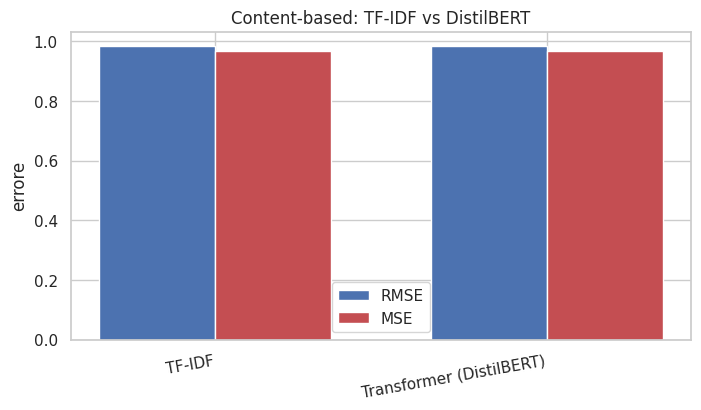

>>> Migliore embedding: Transformer (DistilBERT)
>>> Differenza tra i due: 0.0001 di RMSE


In [25]:
conf = pd.DataFrame([res_tfidf, res_bert]); display(conf)
salva_tab(conf, "tab_06_embedding_CB.csv")
plt.figure(figsize=(8, 4)); x = np.arange(len(conf)); w = 0.35
plt.bar(x - w/2, conf["RMSE"], w, label="RMSE", color="#4C72B0")
plt.bar(x + w/2, conf["MSE"], w, label="MSE", color="#C44E52")
plt.xticks(x, conf["embedding"], rotation=10, ha="right"); plt.ylabel("errore"); plt.legend()
plt.title("Content-based: TF-IDF vs DistilBERT")
salva_fig("fig_08_embedding_CB.png"); plt.show()
print(">>> Migliore embedding:", conf.loc[conf["RMSE"].idxmin(), "embedding"])
print(f">>> Differenza tra i due: {abs(res_tfidf['RMSE'] - res_bert['RMSE']):.4f} di RMSE")

## 2.6 — Confronto Content-Based vs Collaborative Filtering (stesso split)
Per un confronto onesto ri-alleno il collaborative filtering **sullo stesso split 80/20** e lo
valuto sulle **stesse coppie di test** del content-based: cosi i due approcci sono misurati
sugli stessi utenti e prodotti, con lo stesso protocollo.

Coppie di test comuni CB/CF: 28,373
[CF stesso split] SVD: RMSE=0.9498
[CF stesso split] KNNBasic: RMSE=1.0710
CF di riferimento per il confronto: {'approccio': 'Collaborative Filtering (SVD, stesso split)', 'RMSE': 0.9498, 'MSE': 0.902}


,approccio,RMSE,MSE
0,"Collaborative Filtering (SVD, stesso split)",0.9498,0.9020
1,Content-Based (DistilBERT),0.9835,0.9673
2,Content-Based (TF-IDF),0.9836,0.9674
3,"Collaborative Filtering (KNNBasic, stesso split)",1.0710,1.1470


[tabella] ./report/figure/tab_07_CB_vs_CF.csv
[figura] ./report/figure/fig_09_CB_vs_CF.png


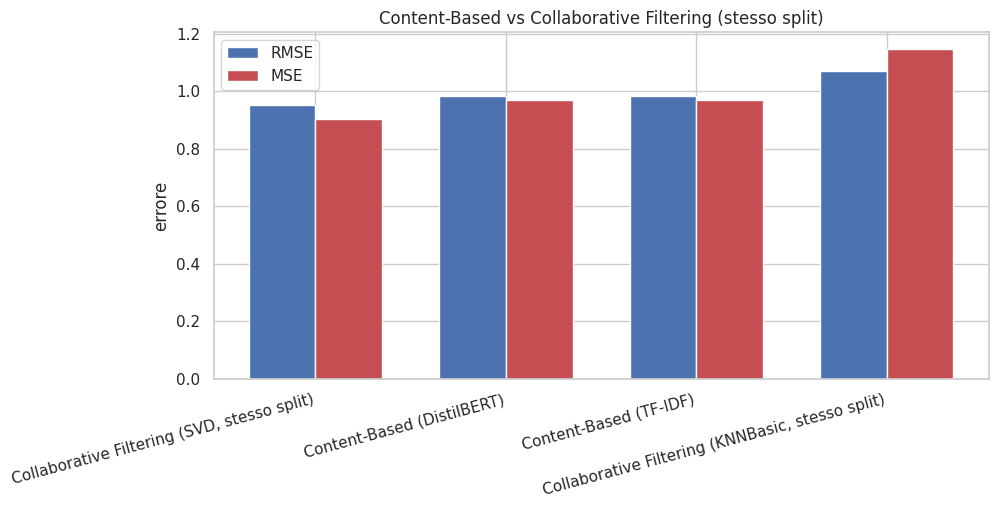

>>> Margine del CF sul miglior content-based: 0.0337 di RMSE


In [26]:
# Confronto Content-Based vs Collaborative Filtering.
# Per un confronto equo ri-valuto il CF sullo STESSO split 80/20 e sulle STESSE coppie di
# test del content-based (stessi utenti e item), invece di riusare la cross-validation della
# Parte 1 (protocollo diverso).
# Il riferimento e l'SVD con i PARAMETRI PREDEFINITI di Surprise, non quelli vincenti della
# grid search del cap. 1.6: e una scelta conservativa, penalizza il CF nel confronto e rende
# piu solido il risultato se vince comunque. Il KNNBasic e riportato come termine di paragone.
from surprise import Dataset, Reader, KNNBasic, SVD, accuracy

reader_cf = Reader(rating_scale=(1, 5))
train_cf = Dataset.load_from_df(df_train_cb[[ID_UTENTE, ID_ITEM, "rating"]], reader_cf).build_full_trainset()

# Stesse coppie di test valutate dal content-based
mask_eval = df_test_cb[ID_UTENTE].isin(train_by_user) & df_test_cb[ID_ITEM].isin(item_pos)
testset_cf = list(df_test_cb.loc[mask_eval, [ID_UTENTE, ID_ITEM, "rating"]].itertuples(index=False, name=None))
print(f"Coppie di test comuni CB/CF: {len(testset_cf):,}")

righe_cf = []
for nome_cf, algo_cf in [("SVD", SVD(random_state=RANDOM_STATE)),
                         ("KNNBasic", KNNBasic(sim_options={"name": "cosine", "user_based": False}, verbose=False))]:
    algo_cf.fit(train_cf)
    rmse_cf = float(accuracy.rmse(algo_cf.test(testset_cf), verbose=False))
    print(f"[CF stesso split] {nome_cf}: RMSE={rmse_cf:.4f}")
    righe_cf.append({"approccio": f"Collaborative Filtering ({nome_cf}, stesso split)",
                     "RMSE": round(rmse_cf, 4), "MSE": round(rmse_cf ** 2, 4)})
    del algo_cf; gc.collect()

# Riferimento del report: l'SVD (prima riga), come dichiarato nel capitolo 5.4
riga_cf = righe_cf[0]
print("CF di riferimento per il confronto:", riga_cf)

righe = [{"approccio": "Content-Based (TF-IDF)",     "RMSE": res_tfidf["RMSE"], "MSE": res_tfidf["MSE"]},
         {"approccio": "Content-Based (DistilBERT)", "RMSE": res_bert["RMSE"],  "MSE": res_bert["MSE"]}]
conf_fin = pd.DataFrame(righe + righe_cf).sort_values("RMSE").reset_index(drop=True)
display(conf_fin); salva_tab(conf_fin, "tab_07_CB_vs_CF.csv")
salva_risultato("cb_vs_cf", conf_fin.to_dict("records"))

plt.figure(figsize=(10, 4.5)); x = np.arange(len(conf_fin)); w = 0.35
plt.bar(x - w/2, conf_fin["RMSE"], w, label="RMSE", color="#4C72B0")
plt.bar(x + w/2, conf_fin["MSE"], w, label="MSE", color="#C44E52")
plt.xticks(x, conf_fin["approccio"], rotation=15, ha="right"); plt.ylabel("errore"); plt.legend()
plt.title("Content-Based vs Collaborative Filtering (stesso split)")
salva_fig("fig_09_CB_vs_CF.png"); plt.show()
print(f">>> Margine del CF sul miglior content-based: "
      f"{min(res_tfidf['RMSE'], res_bert['RMSE']) - riga_cf['RMSE']:.4f} di RMSE")

## 2.7 — Riepilogo Parte 2
`fig_08`/`tab_06` (confronto embedding), `fig_09`/`tab_07` (CB vs CF). Lettura critica: il CF
di norma ottiene un RMSE piu basso perche sfrutta i co-rating; il CB resta competitivo e ha il
vantaggio di gestire il cold-start dei prodotti nuovi.

# PARTE 3 - Sentiment Analysis (AVANZATO)

_Corrisponde ai **capitoli 6 e 7** del report: classificazione a tre classi con i quattro classificatori del Lab 6 e gestione dello sbilanciamento (cap. 6), bonus con LLM zero-shot via Groq (cap. 7)._

## 3.1 — Caricamento del dataset da HuggingFace
Leggo il file `.jsonl` grezzo via link `hf://` con il builder generico `"json"`: e il modo piu
robusto e non richiede `trust_remote_code`. La categoria contiene milioni di righe, quindi
scarico in **streaming** fermandomi a `MAX_REVIEWS`.

In [27]:
from datasets import load_dataset

# Libero quello che la Parte 3 non usa piu: il DataFrame grezzo della Parte 1 e gli
# embedding dei prodotti. Senza questo passaggio, ricaricare un milione di recensioni
# CON il testo mentre in memoria c'e ancora tutto il resto fa cadere la sessione di Colab.
libera("df", "emb_tfidf", "emb_bert", "meta_core", "testi", "df_core", "df_train_cb",
       "gia_visti", "R_hat", "trainset", "dati_surprise", "top_n_df")

def carica_recensioni_testo(category, max_rows=MAX_REVIEWS):
    """Streaming delle sole colonne che servono al sentiment: rating, title, text.

    La versione precedente accumulava l'esempio INTERO (comprese le immagini in tre
    risoluzioni) e filtrava le colonne solo dopo aver costruito il DataFrame: alcuni GB
    inutili, ed e li che il runtime esauriva la RAM.
    """
    url = f"hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw/review_categories/{category}.jsonl"
    ds = load_dataset("json", data_files=url, split="train", streaming=True)
    ds = ds.shuffle(seed=RANDOM_STATE, buffer_size=100000)   # mescolo per avere un campione vario

    righe = []
    for esempio in ds:
        righe.append((esempio.get("rating"), esempio.get("title"), esempio.get("text")))
        if len(righe) >= max_rows:
            break
    return pd.DataFrame(righe, columns=["rating", "title", "text"])

print(f"Scarico fino a {MAX_REVIEWS:,} recensioni della categoria {CATEGORY}...")
t0 = time.time()
df = carica_recensioni_testo(CATEGORY)
df = df.dropna(subset=["rating", "text"]).reset_index(drop=True)
df["rating"] = df["rating"].astype("float32")
print(f"Recensioni caricate: {len(df):,} in {(time.time()-t0)/60:.1f} min "
      f"(~{df.memory_usage(deep=True).sum()/1e6:.0f} MB in memoria)")
display(df.head(3))

Scarico fino a 1,000,000 recensioni della categoria Movies_and_TV...
Recensioni caricate: 1,000,000 in 1.1 min (~410 MB in memoria)


,rating,title,text
0,4.0,Ok it's moronic....but I like it,Sometimes I like silly little musicals. This q...
1,1.0,Didn't get to view whole movie,Got cut off would be nice to view entire movie.
2,5.0,We had to keep watching,We would give it a ten! How good can actors b...


## 3.2 — Costruzione dell'etichetta di sentiment
Rating 1-2 → negativo, 3 → neutro, 4-5 → positivo. Come tipico su Amazon i voti positivi
dominano e la classe **neutro** e molto rara: lo sbilanciamento andra gestito nella
classificazione.

Distribuzione delle classi di sentiment (sul campione grezzo, senza deduplicazione):
  negativo :   114,946  (11.5%)
  neutro   :    89,339  (8.9%)
  positivo :   795,715  (79.6%)


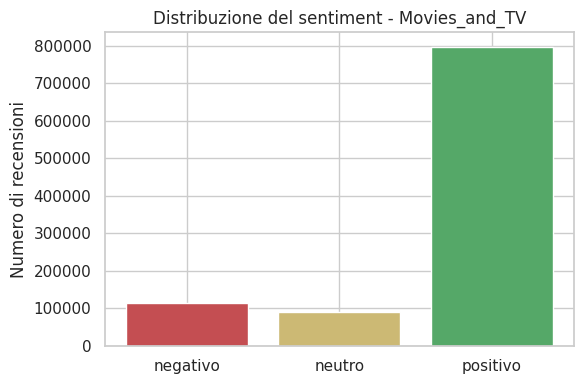

In [28]:
def rating_to_sentiment(r):
    if r <= 2:
        return 0     # negativo
    elif r == 3:
        return 1     # neutro
    else:
        return 2     # positivo

df["sentiment"] = df["rating"].apply(rating_to_sentiment).astype("int8")
NOMI = {0: "negativo", 1: "neutro", 2: "positivo"}

distribuzione = df["sentiment"].map(NOMI).value_counts()
print("Distribuzione delle classi di sentiment (sul campione grezzo, senza deduplicazione):")
for c in ["negativo", "neutro", "positivo"]:
    n = int(distribuzione.get(c, 0))
    print(f"  {c:9s}: {n:>9,}  ({n/len(df)*100:.1f}%)")
salva_risultato("sentiment_distribuzione", {c: int(distribuzione.get(c, 0)) for c in NOMI.values()})
salva_risultato("sentiment_base_recensioni", int(len(df)))

plt.figure(figsize=(6, 4))
colori = {"negativo": "#C44E52", "neutro": "#CCB974", "positivo": "#55A868"}
ordine = ["negativo", "neutro", "positivo"]
plt.bar(ordine, [distribuzione.get(c, 0) for c in ordine], color=[colori[c] for c in ordine])
plt.title(f"Distribuzione del sentiment - {CATEGORY}")
plt.ylabel("Numero di recensioni")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_10_distribuzione_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.3 — Campione stratificato
Estraggo `SAMPLE_SIZE` recensioni in modo **stratificato**, cosi le proporzioni fra le classi
restano quelle reali e la valutazione e realistica.

In [29]:
# Campionamento stratificato: prendo da ogni classe la stessa frazione, cosi le
# proporzioni reali (e quindi la difficolta del problema) restano invariate.
frazione = min(SAMPLE_SIZE / len(df), 1.0)
df_s = (df.groupby("sentiment", group_keys=False)
          .sample(frac=frazione, random_state=RANDOM_STATE)
          .reset_index(drop=True))
print(f"Dimensione del campione: {len(df_s):,} (frazione {frazione:.4f})")
print(df_s["sentiment"].map(NOMI).value_counts())

# Il milione di recensioni non serve piu: tengo solo il campione.
libera("df", "distribuzione")

Dimensione del campione: 40,001 (frazione 0.0400)
sentiment
positivo    31829
negativo     4598
neutro       3574
Name: count, dtype: int64


## 3.4 — Preprocessing NLP del testo (Lab 9)
Tokenizzazione con `word_tokenize`, rimozione delle stopword inglesi e **lemmatizzazione**.
Unisco titolo e corpo della recensione perche il titolo contiene spesso gia il giudizio.

In [30]:
import nltk
for risorsa in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.download(risorsa, quiet=True)
    except Exception as e:
        print("Problema nel download di", risorsa, ":", e)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

STOPWORD = set(stopwords.words("english"))
lemmatizzatore = WordNetLemmatizer()

def preprocessa(testo):
    tokens = word_tokenize(str(testo))
    tokens = [t for t in tokens if t.casefold() not in STOPWORD]
    tokens = [lemmatizzatore.lemmatize(t.lower()) for t in tokens if t.isalpha() and len(t) > 2]
    return " ".join(tokens)

t0 = time.time()
df_s["testo_grezzo"] = (df_s["title"].fillna("") + ". " + df_s["text"].fillna(""))  # per transformer e LLM
df_s["testo"] = df_s["testo_grezzo"].apply(preprocessa)                             # pulito: per il TF-IDF
n_prima_pulizia = len(df_s)
df_s = df_s[df_s["testo"].str.len() > 0].reset_index(drop=True)
print(f"Preprocessing di {n_prima_pulizia:,} recensioni completato in {time.time()-t0:.0f}s")
print(f"Scartate perche vuote dopo la pulizia: {n_prima_pulizia - len(df_s):,} | restano {len(df_s):,}")
salva_risultato("sentiment_campione", {"estratte": n_prima_pulizia, "usate": len(df_s)})
display(df_s[["rating", "sentiment", "testo"]].head(3))

Preprocessing di 40,001 recensioni completato in 18s
Scartate perche vuote dopo la pulizia: 101 | restano 39,900


,rating,sentiment,testo
0,2.0,0,interesting anthropology drama interesting see...
1,2.0,0,new star trek officially becomes video game in...
2,2.0,0,boring neither depth plot development characte...


## 3.5 — Suddivisione train/test (stratificata)

In [31]:
from sklearn.model_selection import train_test_split

# .astype(str).to_numpy() e non .values: da pandas 3 le colonne di testo sono Arrow-backed
# e .values restituisce un ExtensionArray che train_test_split non sa indicizzare.
X_testo = df_s["testo"].astype(str).to_numpy()           # pulito: per il TF-IDF
X_grezzo = df_s["testo_grezzo"].astype(str).to_numpy()   # grezzo: per il transformer e per l'LLM
y = df_s["sentiment"].to_numpy()
X_train_txt, X_test_txt, X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_testo, X_grezzo, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Training:", len(X_train_txt), "| Test:", len(X_test_txt))
salva_risultato("sentiment_split", {"train": int(len(X_train_txt)), "test": int(len(X_test_txt))})

Training: 31920 | Test: 7980


{'train': 31920, 'test': 7980}

## 3.6 — Embedding A: TF-IDF (Lab 9)

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=TFIDF_MAX_FEATURES)
X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf = tfidf.transform(X_test_txt)
print("Matrice TF-IDF - training:", X_train_tfidf.shape, "| test:", X_test_tfidf.shape)

Matrice TF-IDF - training: (31920, 10000) | test: (7980, 10000)


## 3.7 — Embedding B: Transformer (Lab 10)
Come nel Lab 10 uso la libreria `transformers`: `distilbert-base-uncased` con **mean-pooling**
del `last_hidden_state`. Al transformer passo il **testo grezzo** (titolo + corpo): e addestrato
sul linguaggio naturale, quindi il preprocessing che aiuta il TF-IDF a lui toglie informazione.

In [33]:
import torch
from transformers import AutoTokenizer, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device in uso:", device)

# Cache su disco: se il runtime si riavvia non ricalcolo gli embedding da capo.
path_emb_tr = os.path.join(DATA_DIR, f"emb_distilbert_sent_train_{len(X_train_raw)}.npy")
path_emb_te = os.path.join(DATA_DIR, f"emb_distilbert_sent_test_{len(X_test_raw)}.npy")

def mean_pooling(last_hidden_state, attention_mask):
    maschera = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    return (last_hidden_state * maschera).sum(1) / maschera.sum(1).clamp(min=1e-9)

if os.path.exists(path_emb_tr) and os.path.exists(path_emb_te):
    X_train_bert = np.load(path_emb_tr); X_test_bert = np.load(path_emb_te)
    print("Embedding ricaricati dalla cache - training", X_train_bert.shape)
else:
    tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_EMB)
    modello_bert = AutoModel.from_pretrained(HF_MODEL_EMB).to(device).eval()

    @torch.no_grad()
    def calcola_embedding(testi_in, batch=64, max_len=128):
        vettori = []
        for i in range(0, len(testi_in), batch):
            blocco = list(testi_in[i:i + batch])
            enc = tokenizer(blocco, padding=True, truncation=True, max_length=max_len, return_tensors="pt").to(device)
            uscita = modello_bert(**enc).last_hidden_state
            vettori.append(mean_pooling(uscita, enc["attention_mask"]).cpu().numpy())
        return np.vstack(vettori)

    # Anche qui il transformer riceve il testo GREZZO (il pulito resta per il TF-IDF)
    t0 = time.time()
    X_train_bert = calcola_embedding(X_train_raw)
    X_test_bert = calcola_embedding(X_test_raw)
    np.save(path_emb_tr, X_train_bert); np.save(path_emb_te, X_test_bert)
    print(f"Embedding transformer calcolati in {(time.time()-t0)/60:.1f} min - training {X_train_bert.shape}")
    # Libero il modello: il cap. 8.3 carica un sentence-transformer piu grande.
    libera("modello_bert", "tokenizer")
    if torch.cuda.is_available(): torch.cuda.empty_cache()

Device in uso: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding transformer calcolati in 2.4 min - training (31920, 768)


## 3.8 — Classificatori del Lab 6 e gestione dello sbilanciamento
Uso i quattro classificatori del Lab 6: **Decision Tree, Random Forest, Gaussian Naive Bayes,
K-Nearest Neighbors**. Sulle feature dense (transformer) applico `StandardScaler`. Per lo
sbilanciamento: `class_weight="balanced"` dove il modello lo supporta, **oversampling** altrove.
Metrica principale: **F1 macro**.

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
from imblearn.over_sampling import RandomOverSampler

def valuta_modello(nome, classificatore, X_tr, X_te, y_tr, y_te, oversampling=False):
    if oversampling:
        X_tr, y_tr = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(X_tr, y_tr)
    t0 = time.time()
    classificatore.fit(X_tr, y_tr)
    secondi = time.time() - t0
    y_pred = classificatore.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="macro", zero_division=0)
    print(f"[{nome}] accuracy={acc:.3f}  precision={prec:.3f}  recall={rec:.3f}  F1_macro={f1:.3f}  ({secondi:.0f}s)")
    return {"modello": nome, "accuracy": round(acc, 4), "precision_macro": round(prec, 4),
            "recall_macro": round(rec, 4), "f1_macro": round(f1, 4),
            "secondi_addestramento": round(secondi, 1)}, y_pred

risultati = []
miglior_f1 = -1
miglior_nome = None
miglior_pred = None

In [35]:
# === Classificatori sull'embedding TF-IDF (matrice sparsa) ===
# GaussianNB richiede dati densi: su TF-IDF uso Decision Tree, Random Forest e KNN.
modelli_tfidf = [
    ("Decision Tree (TF-IDF)", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE), False),
    ("Random Forest (TF-IDF)", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                      n_jobs=2, random_state=RANDOM_STATE), False),
    ("KNN k=5 (TF-IDF)",       KNeighborsClassifier(n_neighbors=5), True),
]
for nome, clf, oversamp in modelli_tfidf:
    risultato, y_pred = valuta_modello(nome, clf, X_train_tfidf, X_test_tfidf, y_train, y_test, oversampling=oversamp)
    risultati.append(risultato)
    if risultato["f1_macro"] > miglior_f1:
        miglior_f1, miglior_nome, miglior_pred = risultato["f1_macro"], nome, y_pred

[Decision Tree (TF-IDF)] accuracy=0.785  precision=0.571  recall=0.608  F1_macro=0.587  (12s)
[Random Forest (TF-IDF)] accuracy=0.861  precision=0.870  recall=0.553  F1_macro=0.621  (91s)
[KNN k=5 (TF-IDF)] accuracy=0.501  precision=0.452  recall=0.511  F1_macro=0.397  (0s)


In [36]:
# === Classificatori sull'embedding transformer (denso, con StandardScaler) ===
# Lo scaler viene addestrato SOLO sul training set: adattarlo anche al test farebbe
# filtrare informazione dal test all'addestramento.
scaler = StandardScaler()
X_train_bert_s = scaler.fit_transform(X_train_bert)
X_test_bert_s = scaler.transform(X_test_bert)

modelli_bert = [
    ("Decision Tree (Transformer)", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE), False),
    ("Random Forest (Transformer)", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                                          n_jobs=2, random_state=RANDOM_STATE), False),
    ("Gaussian NB (Transformer)",   GaussianNB(), True),
    ("KNN k=5 (Transformer)",       KNeighborsClassifier(n_neighbors=5), True),
]
for nome, clf, oversamp in modelli_bert:
    risultato, y_pred = valuta_modello(nome, clf, X_train_bert_s, X_test_bert_s, y_train, y_test, oversampling=oversamp)
    risultati.append(risultato)
    if risultato["f1_macro"] > miglior_f1:
        miglior_f1, miglior_nome, miglior_pred = risultato["f1_macro"], nome, y_pred

print(f"\nMiglior classificatore per F1 macro: {miglior_nome} ({miglior_f1:.3f})")
salva_risultato("sentiment_classificatori", risultati)
salva_risultato("sentiment_migliore", {"nome": miglior_nome, "f1_macro": miglior_f1})
np.save(os.path.join(RES_DIR, "pred_miglior_classificatore.npy"), miglior_pred)
np.save(os.path.join(RES_DIR, "y_test_sentiment.npy"), y_test)

[Decision Tree (Transformer)] accuracy=0.767  precision=0.522  recall=0.523  F1_macro=0.522  (80s)
[Random Forest (Transformer)] accuracy=0.830  precision=0.858  recall=0.440  F1_macro=0.473  (231s)
[Gaussian NB (Transformer)] accuracy=0.660  precision=0.510  recall=0.628  F1_macro=0.522  (0s)
[KNN k=5 (Transformer)] accuracy=0.731  precision=0.529  recall=0.616  F1_macro=0.551  (0s)

Miglior classificatore per F1 macro: Random Forest (TF-IDF) (0.621)


## 3.9 — Confronto dei classificatori e confusion matrix

Confronto dei classificatori (ordinati per F1 macro):


,modello,accuracy,precision_macro,recall_macro,f1_macro,secondi_addestramento
0,Random Forest (TF-IDF),0.8613,0.8695,0.5529,0.6207,91.4
1,Decision Tree (TF-IDF),0.7853,0.5708,0.6084,0.5869,12.3
2,KNN k=5 (Transformer),0.7312,0.5289,0.6165,0.5515,0.0
3,Decision Tree (Transformer),0.7670,0.5221,0.5226,0.5223,79.6
4,Gaussian NB (Transformer),0.6596,0.5096,0.6278,0.5220,0.4
5,Random Forest (Transformer),0.8299,0.8577,0.4403,0.4730,230.6
6,KNN k=5 (TF-IDF),0.5014,0.4520,0.5109,0.3973,0.0


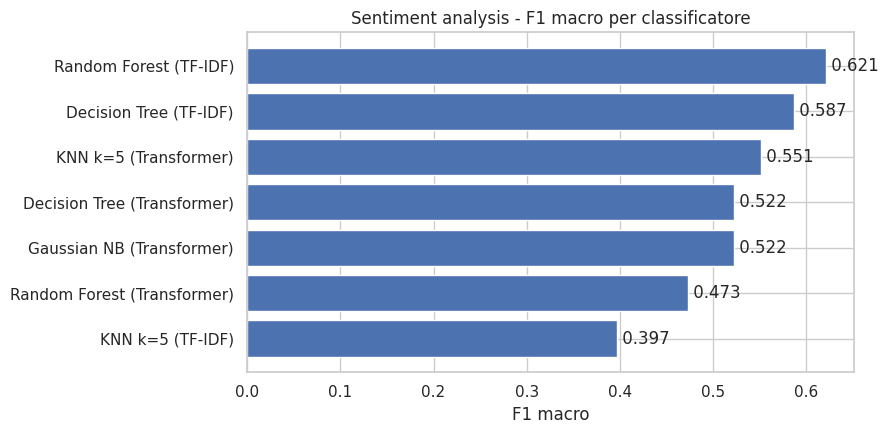

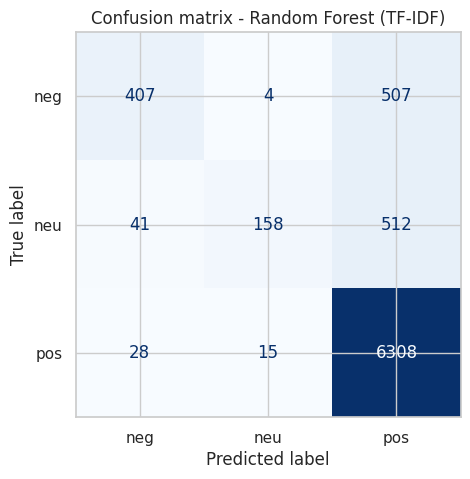

Report dettagliato del modello migliore:
              precision    recall  f1-score   support

    negativo       0.86      0.44      0.58       918
      neutro       0.89      0.22      0.36       711
    positivo       0.86      0.99      0.92      6351

    accuracy                           0.86      7980
   macro avg       0.87      0.55      0.62      7980
weighted avg       0.86      0.86      0.83      7980



In [37]:
tabella = pd.DataFrame(risultati).sort_values("f1_macro", ascending=False).reset_index(drop=True)
print("Confronto dei classificatori (ordinati per F1 macro):")
display(tabella)
tabella.to_csv(f"{FIG_DIR}/tab_11_classificatori_sentiment.csv", index=False)

plt.figure(figsize=(9, 4.5))
plt.barh(tabella["modello"], tabella["f1_macro"], color="#4C72B0")
plt.gca().invert_yaxis()
plt.xlabel("F1 macro")
plt.title("Sentiment analysis - F1 macro per classificatore")
for i, v in enumerate(tabella["f1_macro"]):
    plt.text(v, i, f" {v:.3f}", va="center")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_11_confronto_classificatori.png", dpi=150, bbox_inches="tight")
plt.show()

cm = confusion_matrix(y_test, miglior_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["neg", "neu", "pos"])
fig, ax = plt.subplots(figsize=(5.5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion matrix - {miglior_nome}")
plt.savefig(f"{FIG_DIR}/fig_12_confusion_matrix_best.png", dpi=150, bbox_inches="tight")
plt.show()

print("Report dettagliato del modello migliore:")
print(classification_report(y_test, miglior_pred, target_names=["negativo", "neutro", "positivo"], zero_division=0))

## 3.10 — Accuracy vs F1 macro (l'effetto dello sbilanciamento)
Molti modelli hanno accuracy alta ma F1 macro molto piu bassa: e la prova visiva che
"azzeccano" la classe positiva dominante e sbagliano le classi rare.

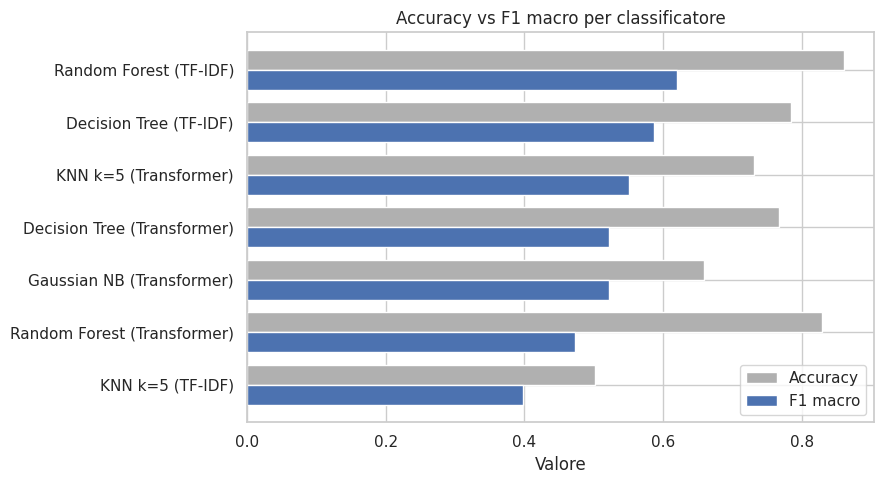

In [38]:
tab2 = tabella.sort_values("f1_macro", ascending=True)
y_pos = np.arange(len(tab2))
h = 0.38
plt.figure(figsize=(9, 5))
plt.barh(y_pos + h/2, tab2["accuracy"], height=h, label="Accuracy", color="#B0B0B0")
plt.barh(y_pos - h/2, tab2["f1_macro"], height=h, label="F1 macro", color="#4C72B0")
plt.yticks(y_pos, tab2["modello"])
plt.xlabel("Valore")
plt.title("Accuracy vs F1 macro per classificatore")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_11b_accuracy_vs_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.11 — Metriche per classe del modello migliore
Mostrano quale classe e piu difficile: tipicamente il **neutro**, che e anche la piu rara.

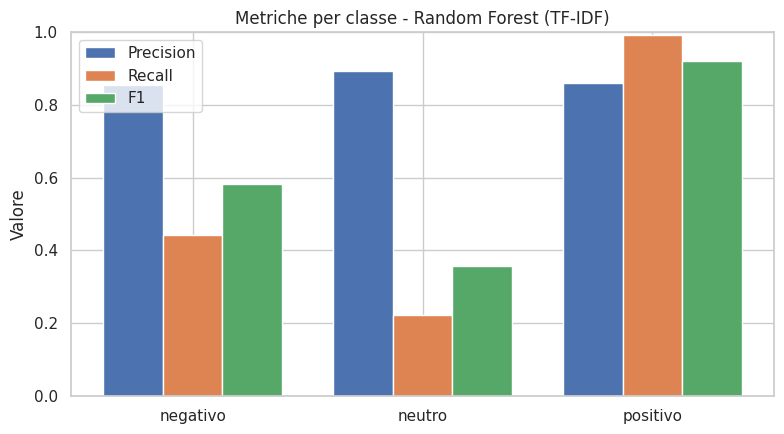

In [39]:
rep = classification_report(y_test, miglior_pred, target_names=["negativo", "neutro", "positivo"],
                            output_dict=True, zero_division=0)
classi = ["negativo", "neutro", "positivo"]
prec = [rep[c]["precision"] for c in classi]
rec  = [rep[c]["recall"]    for c in classi]
f1c  = [rep[c]["f1-score"]  for c in classi]
salva_risultato("sentiment_per_classe_migliore",
                {c: {"precision": round(rep[c]["precision"], 4), "recall": round(rep[c]["recall"], 4),
                     "f1": round(rep[c]["f1-score"], 4)} for c in classi})

x = np.arange(len(classi)); w = 0.26
plt.figure(figsize=(8, 4.5))
plt.bar(x - w, prec, w, label="Precision", color="#4C72B0")
plt.bar(x,     rec,  w, label="Recall",    color="#DD8452")
plt.bar(x + w, f1c,  w, label="F1",        color="#55A868")
plt.xticks(x, classi); plt.ylim(0, 1); plt.ylabel("Valore")
plt.title(f"Metriche per classe - {miglior_nome}")
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_12b_metriche_per_classe.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.12 — Confusion matrix normalizzata
Ogni riga somma a 1: piu leggibile per la classe "neutro", che ha pochi esempi.

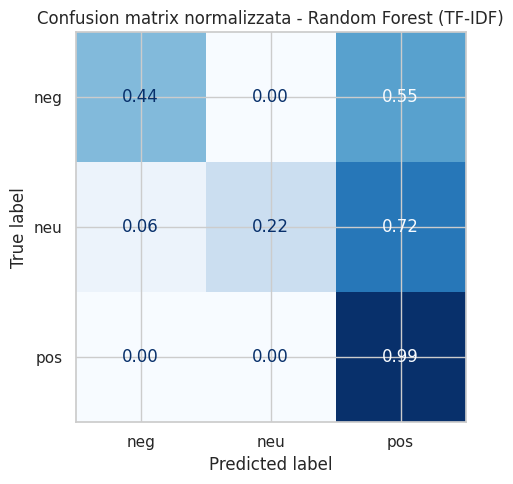

In [40]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, miglior_pred, display_labels=["neg", "neu", "pos"],
    normalize="true", cmap="Blues", values_format=".2f", colorbar=False, ax=ax)
ax.set_title(f"Confusion matrix normalizzata - {miglior_nome}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_12c_confusion_matrix_norm.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.13 — BONUS: sentiment con LLM (Lab 11, Groq)
Classifico `N_LLM` recensioni con un **LLM** servito da **Groq** (`ChatGroq`, modello impostato
in `GROQ_MODEL`, `temperature=0`) e prompt "rispondi solo con l'etichetta". Serve una
`GROQ_API_KEY` gratuita; in mancanza c'e un fallback su un modello HuggingFace zero-shot.
Alla fine confronto l'LLM con il classificatore classico sullo stesso sottoinsieme.

In [41]:
import os, getpass
if not os.environ.get("GROQ_API_KEY"):
    try:
        os.environ["GROQ_API_KEY"] = getpass.getpass("GROQ_API_KEY (invio per il fallback HuggingFace): ")
    except Exception:
        pass

# Le N_LLM recensioni sono estratte con un RNG dedicato e SEMINATO: senza seed il
# sottoinsieme cambiava a ogni esecuzione e i numeri del confronto non erano riproducibili.
rng_llm = np.random.default_rng(RANDOM_STATE)
indici = rng_llm.choice(len(X_test_txt), min(N_LLM, len(X_test_txt)), replace=False)
# All'LLM passo il TESTO GREZZO (non quello pre-processato): rende molto meglio.
testi_llm = [X_test_raw[i] for i in indici]
y_llm_vero = y_test[indici]
mappa_label = {"negative": 0, "neutral": 1, "positive": 2}
USA_GROQ = bool(os.environ.get("GROQ_API_KEY"))

# Cache delle risposte: una chiamata per recensione costa tempo e consuma il rate limit
# del piano gratuito, quindi se il file esiste gia non richiamo l'API.
path_llm = os.path.join(RES_DIR, f"predizioni_llm_{N_LLM}.csv")

if USA_GROQ:
    from langchain_groq import ChatGroq
    llm = ChatGroq(model=GROQ_MODEL, temperature=0)
    def classifica_llm(testo):
        prompt = ("Classify the sentiment of this product review as exactly one word: "
                  "negative, neutral or positive.\n\n"
                  f"Review: {testo[:1000]}\n\nSentiment:")
        risposta = llm.invoke(prompt).content.strip().lower()
        # i modelli "reasoning" possono citare piu etichette nel ragionamento:
        # prendo l'ULTIMA menzionata, che di solito e la risposta finale.
        scelta, pos = 1, -1
        for etichetta, valore in mappa_label.items():
            p = risposta.rfind(etichetta)
            if p > pos:
                pos, scelta = p, valore
        return scelta
    nome_llm = f"Groq {GROQ_MODEL}"
    print("Bonus LLM: uso Groq", GROQ_MODEL)
else:
    from transformers import pipeline
    classificatore_hf = pipeline("zero-shot-classification", model="facebook/bart-large-mnli",
                                 device=0 if torch.cuda.is_available() else -1)
    def classifica_llm(testo):
        out = classificatore_hf(testo[:1000], candidate_labels=["negative", "neutral", "positive"])
        return mappa_label[out["labels"][0]]
    nome_llm = "HuggingFace zero-shot"
    print("Bonus LLM: fallback HuggingFace zero-shot")

if os.path.exists(path_llm):
    _cache = pd.read_csv(path_llm)
    y_llm_pred = _cache["predizione"].to_numpy()
    minuti_llm = float(_cache["minuti"].iloc[0]); n_ripiego = int(_cache["ripieghi"].iloc[0])
    print(f"Predizioni LLM ricaricate dalla cache ({len(y_llm_pred)} recensioni).")
else:
    t0 = time.time(); y_llm_pred = []; primo_errore = True; n_ripiego = 0
    for i, testo in enumerate(testi_llm, 1):
        # Una chiamata puo' fallire per rate limit o timeout: riprovo una seconda volta dopo
        # una pausa e solo se fallisce di nuovo assegno l'etichetta neutra come ripiego.
        for tentativo in (1, 2):
            try:
                y_llm_pred.append(classifica_llm(testo))
                break
            except Exception as e:
                if primo_errore:
                    print("  [!] Primo errore LLM:", repr(e)[:250]); primo_errore = False
                if tentativo == 1:
                    time.sleep(2.0)          # pausa prima del secondo tentativo
                else:
                    y_llm_pred.append(1); n_ripiego += 1
        if i % 50 == 0:
            print(f"  {i}/{len(testi_llm)}")
        if USA_GROQ:
            time.sleep(0.5)   # margine per il rate limit del piano free di Groq
    y_llm_pred = np.array(y_llm_pred)
    minuti_llm = (time.time() - t0) / 60
    pd.DataFrame({"indice_test": indici, "predizione": y_llm_pred, "vero": y_llm_vero,
                  "minuti": minuti_llm, "ripieghi": n_ripiego}).to_csv(path_llm, index=False)

forzati = int((y_llm_pred == 1).sum())
print(f"LLM completato in {minuti_llm:.1f} min | predette 'neutro': {forzati}/{len(y_llm_pred)}"
      f" | di cui assegnate per ripiego dopo due tentativi falliti: {n_ripiego}")
if forzati > 0.8 * len(y_llm_pred):
    print("  [ATTENZIONE] Quasi tutte 'neutro' -> le chiamate LLM falliscono. Leggi il messaggio d'errore sopra.")
salva_risultato("llm_esecuzione", {"modello": nome_llm, "recensioni": int(len(y_llm_pred)),
                                   "minuti": round(minuti_llm, 1), "ripieghi": n_ripiego})

GROQ_API_KEY (invio per il fallback HuggingFace): ··········
Bonus LLM: uso Groq openai/gpt-oss-20b
  50/300
  100/300
  150/300
  200/300
  250/300
  300/300
LLM completato in 12.9 min | predette 'neutro': 21/300 | di cui assegnate per ripiego dopo due tentativi falliti: 0


{'modello': 'Groq openai/gpt-oss-20b',
 'recensioni': 300,
 'minuti': 12.9,
 'ripieghi': 0}

Confronto LLM vs classificatore classico (stesse 300 recensioni):


,approccio,accuracy,f1_macro
0,Classico (Random Forest (TF-IDF)),0.8333,0.5719
1,LLM (Groq openai/gpt-oss-20b),0.8900,0.7543


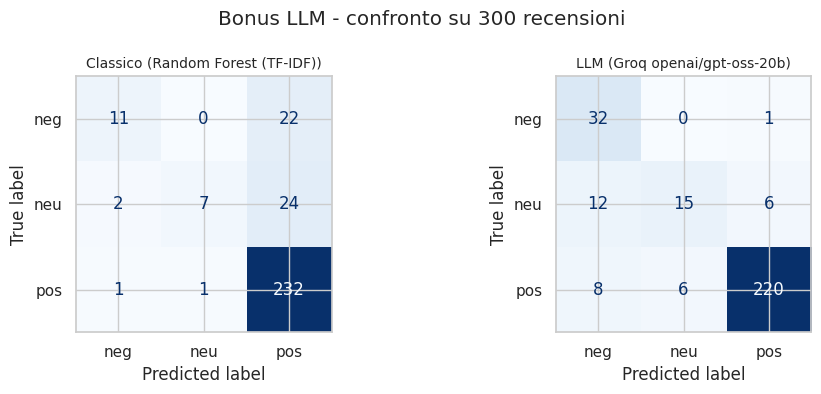

In [42]:
from sklearn.metrics import f1_score

# Il classificatore classico e gia stato addestrato e valutato sull'INTERO test set:
# per il confronto basta ritagliarne le predizioni sulle stesse N_LLM recensioni.
# (La versione precedente riallenava una Random Forest da zero, sprecando minuti e RAM,
#  e ne fissava il nome anche se il migliore fosse stato un altro modello.)
y_classico_pred = miglior_pred[indici]

confronto_llm = pd.DataFrame([
    {"approccio": f"Classico ({miglior_nome})",
     "accuracy": round(accuracy_score(y_llm_vero, y_classico_pred), 4),
     "f1_macro": round(f1_score(y_llm_vero, y_classico_pred, average="macro", zero_division=0), 4)},
    {"approccio": f"LLM ({nome_llm})",
     "accuracy": round(accuracy_score(y_llm_vero, y_llm_pred), 4),
     "f1_macro": round(f1_score(y_llm_vero, y_llm_pred, average="macro", zero_division=0), 4)},
])
print(f"Confronto LLM vs classificatore classico (stesse {len(y_llm_vero)} recensioni):")
display(confronto_llm)
confronto_llm.to_csv(f"{FIG_DIR}/tab_12_LLM_vs_classico.csv", index=False)
salva_risultato("llm_vs_classico", confronto_llm.to_dict("records"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (pred, titolo) in zip(axes, [(y_classico_pred, f"Classico ({miglior_nome})"), (y_llm_pred, f"LLM ({nome_llm})")]):
    ConfusionMatrixDisplay(confusion_matrix(y_llm_vero, pred),
                           display_labels=["neg", "neu", "pos"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(titolo, fontsize=10)
fig.suptitle(f"Bonus LLM - confronto su {len(y_llm_vero)} recensioni")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_13_LLM_vs_classico.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.14 — Conclusioni della Parte 3
- **Sbilanciamento:** la classe *neutro* e la piu rara e difficile; per questo valuto con la
  **F1 macro** e la confusion matrix, non con la sola accuracy.
- **TF-IDF vs Transformer:** confronto le due rappresentazioni sugli stessi classificatori.
- **LLM vs classici:** l'LLM non richiede addestramento ma e piu lento e costoso da chiamare;
  i classificatori classici restano piu pratici su grandi volumi.

Tutte le figure e le tabelle sono salvate in `report/figure/`.

# Conclusioni generali
Ho costruito il progetto in tre fasi: prima un collaborative filtering (K‑NN e SVD con Surprise, k‑core, cross‑validation, filling, K‑Means, top‑N), poi un content‑based (TF‑IDF e transformer, confrontato col CF sullo stesso split), infine la sentiment analysis (i quattro classificatori del Lab 6 con F1 macro, più il bonus LLM). Le figure finiscono in report/figure/, le tabelle di output in report/risultati/; il seed è 42 dappertutto.

---

# CAPITOLO 8 — Analisi aggiuntive fuori programma

Le quattro celle che seguono sono i test extra del capitolo 8 del report: non erano nella traccia, li ho aggiunti io per vedere se qualche modello fuori dal programma faceva meglio di quelli usati nelle Parti 1‑3. Uso gli stessi split e le stesse metriche del resto del progetto, così i confronti sono onesti.

- **8.1** — KNNBaseline (cfr. capitolo 4 del progetto principale)
- **8.2** — SVD sul k-core completo (cfr. capitoli 3 e 4)
- **8.3** — SBERT all-mpnet-base-v2 (cfr. capitolo 5)
- **8.4** — LinearSVC e Logistic Regression (cfr. capitolo 6)

## 8.0 — Ripristino dello stato (da eseguire sempre prima delle celle 8.x)

Le celle del Capitolo 8 riusano risultati calcolati nelle Parti 1-3. Se il runtime si e
riavviato (crash di RAM, disconnessione, timeout di Colab) quelle variabili non esistono piu
e le celle successive fallirebbero con `NameError` o `ModuleNotFoundError`.

Questa cella rimette a posto quello che si puo recuperare da disco senza rifare i calcoli:
il dataset k-core dal parquet, i punteggi dei grid search dal file `risultati_chiave.json`.
Per cio che non e ricostruibile a costo zero (gli embedding del content-based, le feature
del sentiment) stampa l'elenco esatto delle celle da rieseguire.

**Nota**: dopo un riavvio del kernel vanno comunque rieseguite prima le celle **0**, **0.1** e **0.2**.

In [43]:
# =========================================================================
# 8.0  Ripristino dello stato per il Capitolo 8
# =========================================================================
R = leggi_risultati()
print(f"Checkpoint letto: {len(R)} risultati salvati\n")

# --- 1. Dataset Surprise (serve a 8.1) ---
if "dati_surprise" not in globals():
    from surprise import Dataset, Reader
    path_core = os.path.join(DATA_DIR, f"{CATEGORY}_kcore{K_CORE}.parquet")
    if os.path.exists(path_core):
        df_core = pd.read_parquet(path_core)
        dati_surprise = Dataset.load_from_df(df_core[[ID_UTENTE, ID_ITEM, "rating"]], Reader(rating_scale=(1, 5)))
        print(f"[ok] dati_surprise ricostruito dal parquet ({len(df_core):,} rating)")
    else:
        print("[!] parquet del k-core assente: rieseguire le celle 1.1 e 1.3")
else:
    print("[ok] dati_surprise gia in memoria")

# --- 2. Punteggi dei modelli della Parte 1 ---
# Prendo i valori dalle variabili vive; se non ci sono (runtime riavviato),
# li leggo dal checkpoint. Cosi' la tabella riassuntiva di 8.5 resta coerente
# con l'esecuzione corrente anche se i grid dessero valori leggermente diversi.
def _dal_checkpoint(chiave, campo, etichetta):
    if chiave in R and campo in R[chiave]:
        v = R[chiave][campo]
        print(f"[ok] {etichetta} = {v} (dal checkpoint)")
        return v
    print(f"[!] {etichetta} non disponibile: rieseguire la cella corrispondente della Parte 1")
    return None

if "gs_knn" in globals():
    RMSE_KNN_BASIC = round(float(gs_knn.best_score["rmse"]), 4)
    MSE_KNN_BASIC  = round(float(gs_knn.best_score["mse"]), 4)
    print(f"[ok] RMSE_KNN_BASIC = {RMSE_KNN_BASIC} (da gs_knn in memoria)")
else:
    RMSE_KNN_BASIC = _dal_checkpoint("knn_best", "rmse", "RMSE_KNN_BASIC")
    MSE_KNN_BASIC  = _dal_checkpoint("knn_best", "mse",  "MSE_KNN_BASIC")

if "gs_svd" in globals():
    RMSE_SVD = round(float(gs_svd.best_score["rmse"]), 4)
    SVD_BEST_PARAMS = dict(gs_svd.best_params["rmse"])
    print(f"[ok] RMSE_SVD = {RMSE_SVD} (da gs_svd in memoria)")
else:
    RMSE_SVD = _dal_checkpoint("svd_best", "rmse", "RMSE_SVD")
    SVD_BEST_PARAMS = R.get("svd_best", {}).get("params", {"n_factors": 50, "n_epochs": 20,
                                                           "lr_all": 0.005, "reg_all": 0.05,
                                                           "random_state": RANDOM_STATE})
print("     configurazione SVD:", SVD_BEST_PARAMS)

# --- 3. Cosa manca e va rieseguito ---
mancanti = []
if "valuta_embedding" not in globals() or "testi_grezzi" not in globals():
    mancanti.append("8.3 -> rieseguire le celle 2.1, 2.2, 2.3 e 2.4 (metadati, embedding, split CB)")
if "X_train_bert_s" not in globals() or "y_train" not in globals():
    mancanti.append("8.4 -> rieseguire le celle 3.1-3.8 (campione sentiment, TF-IDF, transformer)")
if "risultati" not in globals():
    mancanti.append("8.5 -> serve la lista 'risultati' della cella 3.8")

if mancanti:
    print("\nDa rieseguire prima delle celle indicate:")
    for m in mancanti:
        print("  -", m)
else:
    print("\nTutto pronto: le celle 8.1 - 8.5 possono girare.")

Checkpoint letto: 39 risultati salvati

[ok] dati_surprise ricostruito dal parquet (141,863 rating)
[ok] RMSE_KNN_BASIC = 1.063 (da gs_knn in memoria)
[ok] RMSE_SVD = 0.9401 (da gs_svd in memoria)
     configurazione SVD: {'n_factors': 50, 'n_epochs': 20, 'lr_all': 0.005, 'reg_all': 0.05, 'random_state': 42}

Tutto pronto: le celle 8.1 - 8.5 possono girare.


## 8.1 — KNNBaseline: correzione dei bias sul K-NN

È il K‑NN che, prima di calcolare le similarità, sottrae le baseline di utente e prodotto (stimate con ALS). Mi aspetto un RMSE più basso del KNNBasic: se questo pezzo del vantaggio viene dalle baseline, allora l'SVD non batte il K‑NN solo per merito dei fattori latenti.

Grid KNNBaseline in 3.4 min
Best RMSE KNNBaseline: 1.0021 | config: {'k': 40, 'sim_options': {'name': 'cosine', 'user_based': False}, 'bsl_options': {'method': 'als'}}

Confronto Collaborative Filtering (RMSE, 5-fold CV):
        Modello   RMSE
K-NN (KNNBasic) 1.0630
    KNNBaseline 1.0021
            SVD 0.9401
[tabella] ./report/figure/tab_08_1_knnbaseline.csv

- K-NN Basic  -> KNNBaseline : variazione RMSE di -0.0609
  l'aggiunta delle baseline di utente e prodotto riduce l'errore
- KNNBaseline -> SVD         : variazione RMSE di -0.0620
  la fattorizzazione latente aggiunge un guadagno oltre alle baseline
[figura] ./report/figure/fig_08_1_knnbaseline.png


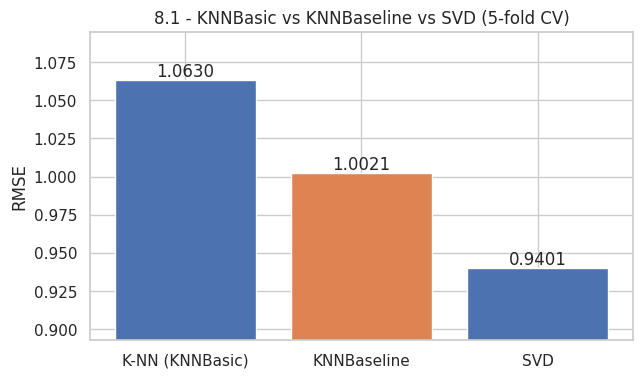

In [44]:
# =========================================================================
# 8.1  KNNBaseline: estensione del confronto CF
# =========================================================================
# Nel capitolo 4 avevo confrontato K-NN (KNNBasic) e SVD. Qui aggiungo il
# KNNBaseline, che prima di calcolare le similarita' sottrae ai rating le
# baseline di utente e prodotto. Serve a capire quanto del vantaggio dell'SVD
# viene dalle baseline (che il KNNBasic non ha) e quanto invece dalla
# fattorizzazione latente.
from surprise import KNNBaseline
from surprise.model_selection import GridSearchCV

# Grid ridotta e riproducibile. verbose=False evita il log di ogni matrice di similarita.
param_grid_knnbl = {
    "k": [20, 40],
    "sim_options": {
        "name": ["cosine", "pearson_baseline"],
        "user_based": [False],
    },
    "bsl_options": {
        "method": ["als"],
    },
    "verbose": [False],
}

# Idempotenza: rifaccio la fit solo se manca o se una precedente e' rimasta a meta
if "gs_knnbl" not in globals() or not hasattr(gs_knnbl, "best_score"):
    t0 = time.time()
    gs_knnbl = GridSearchCV(
        KNNBaseline, param_grid_knnbl,
        measures=["rmse"], cv=CV_FOLDS, n_jobs=1, joblib_verbose=0,
    )
    gs_knnbl.fit(dati_surprise)
    print(f"Grid KNNBaseline in {(time.time()-t0)/60:.1f} min")

RMSE_KNNBL = round(float(gs_knnbl.best_score["rmse"]), 4)
cfg_knnbl = {k: v for k, v in gs_knnbl.best_params["rmse"].items() if k != "verbose"}
print(f"Best RMSE KNNBaseline: {RMSE_KNNBL:.4f} | config: {cfg_knnbl}")
salva_risultato("ext_knnbaseline", {"rmse": RMSE_KNNBL, "params": cfg_knnbl})

# -------------------------------------------------------------------------
# Confronto con K-NN Basic e SVD (valori della cella 8.0: variabili vive o checkpoint)
# -------------------------------------------------------------------------
confronto_cf = pd.DataFrame([
    {"Modello": "K-NN (KNNBasic)", "RMSE": RMSE_KNN_BASIC},
    {"Modello": "KNNBaseline",     "RMSE": RMSE_KNNBL},
    {"Modello": "SVD",             "RMSE": RMSE_SVD},
])
print("\nConfronto Collaborative Filtering (RMSE, 5-fold CV):")
print(confronto_cf.to_string(index=False))
salva_tab(confronto_cf, "tab_08_1_knnbaseline.csv")

delta_baseline = RMSE_KNN_BASIC - RMSE_KNNBL
delta_svd      = RMSE_KNNBL - RMSE_SVD
print(f"\n- K-NN Basic  -> KNNBaseline : variazione RMSE di {-delta_baseline:+.4f}")
print("  " + ("l'aggiunta delle baseline di utente e prodotto riduce l'errore"
              if delta_baseline > 0 else
              "su questi dati le baseline non aiutano il K-NN"))
print(f"- KNNBaseline -> SVD         : variazione RMSE di {-delta_svd:+.4f}")
print("  " + ("la fattorizzazione latente aggiunge un guadagno oltre alle baseline"
              if delta_svd > 0 else
              "qui il K-NN con baseline regge il confronto con l'SVD"))

plt.figure(figsize=(7, 4))
plt.bar(confronto_cf["Modello"], confronto_cf["RMSE"], color=["#4C72B0", "#DD8452", "#4C72B0"])
plt.ylabel("RMSE"); plt.title("8.1 - KNNBasic vs KNNBaseline vs SVD (5-fold CV)")
plt.ylim(min(confronto_cf["RMSE"]) * 0.95, max(confronto_cf["RMSE"]) * 1.03)
for xi, v in enumerate(confronto_cf["RMSE"]):
    plt.text(xi, v, f"{v:.4f}", ha="center", va="bottom")
salva_fig("fig_08_1_knnbaseline.png"); plt.show()

## 8.2 — SVD sul k-core completo (senza cap sugli utenti)

Il tetto sugli utenti l'ho messo per il K‑NN, che con la matrice di similarità utente‑utente satura la RAM in fretta. L'SVD invece regge senza problemi tutti i 33.698 utenti del k‑core: qui lo allena su quel dataset più grande, con la stessa configurazione, per vedere se ottiene un RMSE migliore.

Ricaricato df_core_full da parquet: (463509, 3)
K-core completo: 33,698 utenti | 30,923 prodotti | 463,509 rating
Cross-validation in 0.6 min
SVD (tetti 4000 utenti / 12500 prodotti): RMSE=0.9401
SVD (k-core completo):                                 RMSE=0.9687
Differenza: -0.0286  (non migliora con piu' dati)


,SVD,RMSE
0,tetti (4000 utenti),0.9401
1,k-core completo,0.9687


[tabella] ./report/figure/tab_08_2_svd_cap_vs_full.csv
[figura] ./report/figure/fig_08_2_svd_cap_vs_full.png


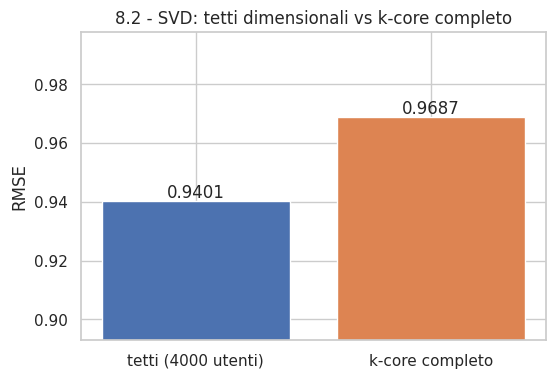

In [45]:
# =========================================================================
# 8.2  SVD sul k-core completo
# =========================================================================
from surprise.model_selection import cross_validate
from surprise import SVD, Reader, Dataset

# Il k-core "completo" (senza tetti su utenti e prodotti) e stato salvato dalla Parte 1
# come parquet: lo ricarico da li, cosi la cella funziona anche dopo un riavvio.
if "df_core_full" not in globals():
    path_core_full = os.path.join(DATA_DIR, f"{CATEGORY}_kcore{K_CORE}_full.parquet")
    df_core_full = pd.read_parquet(path_core_full)
    print(f"Ricaricato df_core_full da parquet: {df_core_full.shape}")

print(f"K-core completo: {df_core_full[ID_UTENTE].nunique():,} utenti | "
      f"{df_core_full[ID_ITEM].nunique():,} prodotti | {len(df_core_full):,} rating")

# Uso la STESSA configurazione vincente trovata dalla grid sul dataset con i tetti.
# SVD_BEST_PARAMS contiene gia random_state: passarlo di nuovo darebbe TypeError.
dati_full = Dataset.load_from_df(df_core_full[[ID_UTENTE, ID_ITEM, "rating"]], Reader(rating_scale=(1, 5)))
t0 = time.time()
cv_full = cross_validate(SVD(**SVD_BEST_PARAMS), dati_full,
                         measures=["rmse", "mse"], cv=CV_FOLDS, n_jobs=1, verbose=False)
rmse_full = float(cv_full["test_rmse"].mean())
rmse_cap  = float(RMSE_SVD)
print(f"Cross-validation in {(time.time()-t0)/60:.1f} min")
print(f"SVD (tetti {USERS_CAP} utenti / {ITEMS_CAP} prodotti): RMSE={rmse_cap:.4f}")
print(f"SVD (k-core completo):                                 RMSE={rmse_full:.4f}")
print(f"Differenza: {rmse_cap - rmse_full:+.4f}  "
      f"({'migliora' if rmse_full < rmse_cap else 'non migliora'} con piu' dati)")

conf_svd = pd.DataFrame([
    {"SVD": f"tetti ({USERS_CAP} utenti)", "RMSE": round(rmse_cap, 4)},
    {"SVD": "k-core completo",              "RMSE": round(rmse_full, 4)},
])
display(conf_svd); salva_tab(conf_svd, "tab_08_2_svd_cap_vs_full.csv")
salva_risultato("ext_svd_full", {"rmse_con_tetti": round(rmse_cap, 4), "rmse_kcore_completo": round(rmse_full, 4)})

plt.figure(figsize=(6, 4))
plt.bar(conf_svd["SVD"], conf_svd["RMSE"], color=["#4C72B0", "#DD8452"])
plt.ylabel("RMSE"); plt.title("8.2 - SVD: tetti dimensionali vs k-core completo")
plt.ylim(min(conf_svd["RMSE"]) * 0.95, max(conf_svd["RMSE"]) * 1.03)
for xi, v in enumerate(conf_svd["RMSE"]):
    plt.text(xi, v, f"{v:.4f}", ha="center", va="bottom")
salva_fig("fig_08_2_svd_cap_vs_full.png"); plt.show()
libera("df_core_full", "dati_full")

## 8.3 — Terzo embedding: sentence-transformers (all-mpnet-base-v2)

Modello sentence-transformer ottimizzato per la similarità semantica tra testi. Lo aggiungo per verificare se un embedding costruito esplicitamente per il matching testuale batte TF-IDF e DistilBERT (test 8.3 del report).

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/196 [00:00<?, ?it/s]

Embedding sentence-transformers (all-mpnet): (12500, 768)
[SBERT (all-mpnet)] coppie di test valutate=28,373  MSE=0.9678  RMSE=0.9837


,embedding,MSE,RMSE,coppie_test
0,TF-IDF,0.9674,0.9836,28373
1,Transformer (DistilBERT),0.9673,0.9835,28373
2,SBERT (all-mpnet),0.9678,0.9837,28373


[tabella] ./report/figure/tab_08_3_sbert.csv
[figura] ./report/figure/fig_08_3_sbert.png


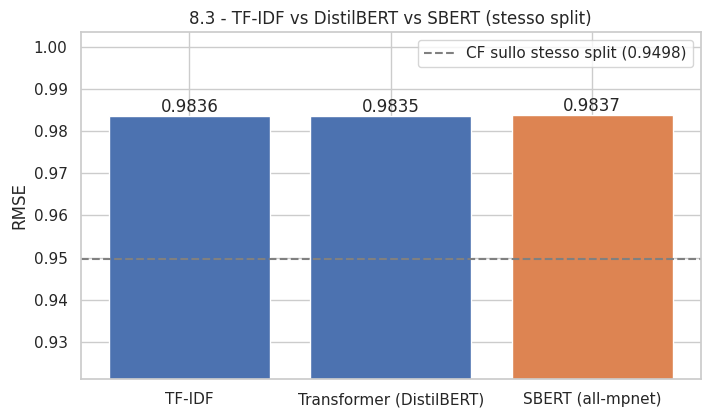

In [46]:
# =========================================================================
# 8.3  SBERT all-mpnet-base-v2
# =========================================================================
from sentence_transformers import SentenceTransformer

# Libero eventuali transformer ancora caricati prima di mpnet (~420 MB):
# tre modelli contemporanei saturano la VRAM del T4 di Colab.
libera("bert", "modello_bert", "tokenizer")
if torch.cuda.is_available(): torch.cuda.empty_cache()

path_emb_st = os.path.join(DATA_DIR, f"emb_mpnet_cb_{len(testi_grezzi)}.npy")
if os.path.exists(path_emb_st):
    emb_st = np.load(path_emb_st)
    print("Embedding SBERT ricaricati dalla cache:", emb_st.shape)
else:
    st_model = SentenceTransformer(HF_MODEL_ST, device=device)
    emb_st = st_model.encode(testi_grezzi, batch_size=64, show_progress_bar=True,
                             convert_to_numpy=True, normalize_embeddings=True)
    np.save(path_emb_st, emb_st)
    print("Embedding sentence-transformers (all-mpnet):", emb_st.shape)
    libera("st_model")
    if torch.cuda.is_available(): torch.cuda.empty_cache()

# Rifaccio il K-NN per utente sull'embedding SBERT usando la funzione valuta_embedding
# gia' definita in Parte 2 (cella 2.4): garantisce STESSO split e stesso protocollo di
# TF-IDF e DistilBERT. emb_st e' allineato agli stessi item perche' testi_grezzi e'
# nello stesso ordine di item_ids, quindi item_pos resta valido.
res_st = valuta_embedding(emb_st, "SBERT (all-mpnet)")
salva_risultato("ext_sbert", res_st)

# Confronto i tre embedding sullo stesso split
conf_3embed = pd.DataFrame([res_tfidf, res_bert, res_st])
display(conf_3embed); salva_tab(conf_3embed, "tab_08_3_sbert.csv")

# Riferimento CF sullo stesso split (calcolato in cap. 2.6)
rmse_cf_ref = riga_cf["RMSE"] if "riga_cf" in globals() and riga_cf is not None else None

plt.figure(figsize=(8, 4.5))
plt.bar(conf_3embed["embedding"], conf_3embed["RMSE"], color=["#4C72B0", "#4C72B0", "#DD8452"])
if rmse_cf_ref is not None:
    plt.axhline(y=rmse_cf_ref, linestyle="--", color="gray",
                label=f"CF sullo stesso split ({rmse_cf_ref:.4f})")
    plt.legend()
plt.ylabel("RMSE"); plt.title("8.3 - TF-IDF vs DistilBERT vs SBERT (stesso split)")
plt.ylim(min(list(conf_3embed["RMSE"]) + [rmse_cf_ref or 99]) * 0.97,
         max(conf_3embed["RMSE"]) * 1.02)
for xi, v in enumerate(conf_3embed["RMSE"]):
    plt.text(xi, v, f"{v:.4f}", ha="center", va="bottom")
salva_fig("fig_08_3_sbert.png"); plt.show()
libera("emb_st")

## 8.4 — Classificatori lineari: LinearSVC e Logistic Regression

I quattro modelli del Lab 6 lasciano scoperta la classe "neutro" (recall 0,24). Provo due modelli lineari — LinearSVC e Logistic Regression — con class_weight="balanced": sui testi vanno spesso bene, quindi voglio vedere se recuperano qualcosa sulle classi rare. Uso le stesse feature, gli stessi split e gli stessi correttivi degli altri.

[LogReg (TF-IDF)] accuracy=0.826  precision=0.648  recall=0.740  F1_macro=0.681  (3s)
[LinearSVC (TF-IDF)] accuracy=0.859  precision=0.683  recall=0.695  F1_macro=0.689  (1s)
[LogReg (Transformer)] accuracy=0.810  precision=0.641  recall=0.741  F1_macro=0.670  (44s)
[LinearSVC (Transformer)] accuracy=0.863  precision=0.689  recall=0.730  F1_macro=0.708  (63s)


,modello,accuracy,precision_macro,recall_macro,f1_macro,secondi_addestramento
0,LinearSVC (Transformer),0.8629,0.6887,0.7305,0.7077,62.6
1,LinearSVC (TF-IDF),0.8586,0.6827,0.6953,0.6886,1.0
2,LogReg (TF-IDF),0.8257,0.6483,0.7397,0.6811,3.4
3,LogReg (Transformer),0.8098,0.6406,0.7412,0.6705,43.7
4,Random Forest (TF-IDF),0.8613,0.8695,0.5529,0.6207,91.4
5,Decision Tree (TF-IDF),0.7853,0.5708,0.6084,0.5869,12.3
6,KNN k=5 (Transformer),0.7312,0.5289,0.6165,0.5515,0.0
7,Decision Tree (Transformer),0.7670,0.5221,0.5226,0.5223,79.6
8,Gaussian NB (Transformer),0.6596,0.5096,0.6278,0.5220,0.4
9,Random Forest (Transformer),0.8299,0.8577,0.4403,0.4730,230.6


[tabella] ./report/figure/tab_08_4_lineari.csv
[figura] ./report/figure/fig_08_4_lineari.png


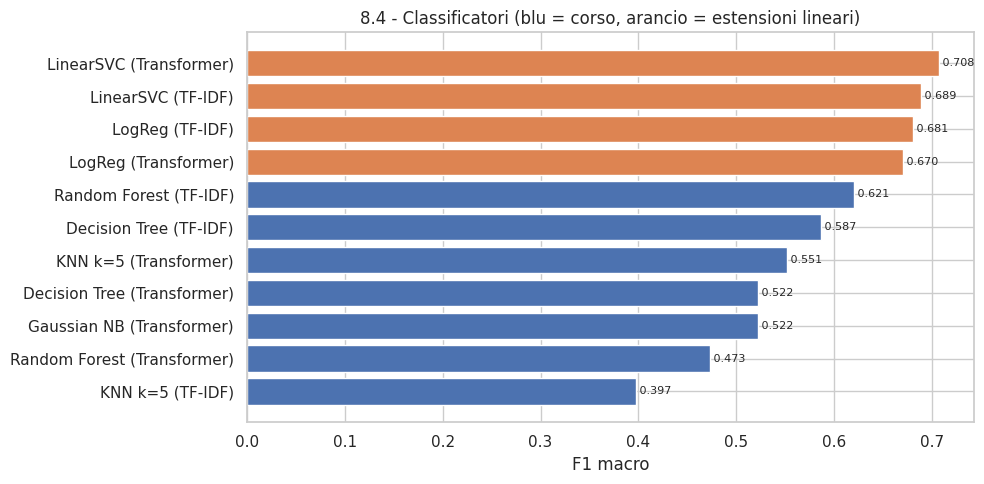


Migliore in assoluto: LinearSVC (Transformer) (F1 macro 0.708)
Migliore fra le estensioni: LinearSVC (Transformer)

LinearSVC (Transformer) - estensione:
              precision    recall  f1-score   support

    negativo       0.68      0.77      0.72       918
      neutro       0.43      0.51      0.47       711
    positivo       0.95      0.92      0.93      6351

    accuracy                           0.86      7980
   macro avg       0.69      0.73      0.71      7980
weighted avg       0.87      0.86      0.87      7980

Random Forest (TF-IDF) - migliore del corso:
              precision    recall  f1-score   support

    negativo       0.86      0.44      0.58       918
      neutro       0.89      0.22      0.36       711
    positivo       0.86      0.99      0.92      6351

    accuracy                           0.86      7980
   macro avg       0.87      0.55      0.62      7980
weighted avg       0.86      0.86      0.83      7980



,classe,recall_corso,recall_estensione
0,negativo,0.4434,0.7658
1,neutro,0.2222,0.5091
2,positivo,0.9932,0.9165


[tabella] ./report/figure/tab_08_4_recall_per_classe.csv
[figura] ./report/figure/fig_08_5_recall_neutro.png


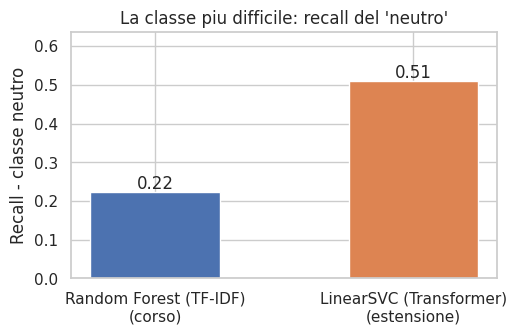

In [47]:
# =========================================================================
# 8.4  LinearSVC e Logistic Regression
# =========================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# Nuovi modelli lineari, valutati sugli stessi split della Parte 3.
# dual="auto" e max_iter alzato evitano i warning di convergenza di sklearn.
modelli_estesi = [
    ("LogReg (TF-IDF)",         LogisticRegression(max_iter=1000, class_weight="balanced"),
     X_train_tfidf,  X_test_tfidf),
    ("LinearSVC (TF-IDF)",      LinearSVC(class_weight="balanced", dual="auto", max_iter=5000),
     X_train_tfidf,  X_test_tfidf),
    ("LogReg (Transformer)",    LogisticRegression(max_iter=1000, class_weight="balanced"),
     X_train_bert_s, X_test_bert_s),
    ("LinearSVC (Transformer)", LinearSVC(class_weight="balanced", dual="auto", max_iter=5000),
     X_train_bert_s, X_test_bert_s),
]

risultati_estesi = []
pred_estesi = {}
for nome, clf, X_tr, X_te in modelli_estesi:
    ris, y_pred = valuta_modello(nome, clf, X_tr, X_te, y_train, y_test, oversampling=False)
    risultati_estesi.append(ris)
    pred_estesi[nome] = y_pred          # conservo le predizioni: non riaddestro nulla dopo

# Confronto con i classificatori del corso
tab_est = (pd.DataFrame(risultati + risultati_estesi)
             .sort_values("f1_macro", ascending=False)
             .reset_index(drop=True))
display(tab_est); salva_tab(tab_est, "tab_08_4_lineari.csv")
salva_risultato("ext_lineari", risultati_estesi)

colori = ["#DD8452" if any(k in n for k in ["LinearSVC", "LogReg"]) else "#4C72B0"
          for n in tab_est["modello"]]
plt.figure(figsize=(10, 5))
plt.barh(tab_est["modello"][::-1], tab_est["f1_macro"][::-1], color=colori[::-1])
plt.xlabel("F1 macro")
plt.title("8.4 - Classificatori (blu = corso, arancio = estensioni lineari)")
for i, v in enumerate(tab_est["f1_macro"][::-1]):
    plt.text(v, i, f" {v:.3f}", va="center", fontsize=8)
plt.tight_layout()
salva_fig("fig_08_4_lineari.png"); plt.show()

# --- Metriche per classe: il migliore delle estensioni contro il migliore del corso ---
# E' il numero su cui si regge il capitolo 8.4 del report: il guadagno di F1 macro
# arriva dalle classi rare, quindi guardo le recall classe per classe.
best_ext_name = max(risultati_estesi, key=lambda r: r["f1_macro"])["modello"]
y_pred_ext = pred_estesi[best_ext_name]     # gia calcolate sopra, nessun riaddestramento
print(f"\nMigliore in assoluto: {tab_est.iloc[0]['modello']} (F1 macro {tab_est.iloc[0]['f1_macro']:.3f})")
print(f"Migliore fra le estensioni: {best_ext_name}\n")

print(f"{best_ext_name} - estensione:")
print(classification_report(y_test, y_pred_ext,
      target_names=["negativo", "neutro", "positivo"], zero_division=0))
print(f"{miglior_nome} - migliore del corso:")
print(classification_report(y_test, miglior_pred,
      target_names=["negativo", "neutro", "positivo"], zero_division=0))

rep_corso = classification_report(y_test, miglior_pred, target_names=["negativo", "neutro", "positivo"],
                                  output_dict=True, zero_division=0)
rep_ext   = classification_report(y_test, y_pred_ext, target_names=["negativo", "neutro", "positivo"],
                                  output_dict=True, zero_division=0)
tab_recall = pd.DataFrame([
    {"classe": c,
     "recall_corso":      round(rep_corso[c]["recall"], 4),
     "recall_estensione": round(rep_ext[c]["recall"], 4)}
    for c in ["negativo", "neutro", "positivo"]
])
display(tab_recall); salva_tab(tab_recall, "tab_08_4_recall_per_classe.csv")
salva_risultato("ext_recall_per_classe", {"migliore_estensione": best_ext_name,
                                          "migliore_corso": miglior_nome,
                                          "recall": tab_recall.to_dict("records")})

# Figura 8.5 del report: la classe piu' difficile
plt.figure(figsize=(5.5, 3.2))
valori = [rep_corso["neutro"]["recall"], rep_ext["neutro"]["recall"]]
plt.bar([f"{miglior_nome}\n(corso)", f"{best_ext_name}\n(estensione)"], valori,
        color=["#4C72B0", "#DD8452"], width=0.5)
for xi, v in enumerate(valori):
    plt.text(xi, v, f"{v:.2f}", ha="center", va="bottom")
plt.ylabel("Recall - classe neutro")
plt.title("La classe piu difficile: recall del 'neutro'")
plt.ylim(0, max(valori) * 1.25)
salva_fig("fig_08_5_recall_neutro.png"); plt.show()

## 8.5 - Il quadro complessivo dei test

Riepilogo dei quattro test. Il risultato che conta davvero è LinearSVC, che alza la F1 macro sui testi. KNNBaseline migliora il K‑NN ma non basta a battere l'SVD. Gli altri due esperimenti (SVD full e SBERT) confermano che le scelte fatte prima non erano da rivedere.

In [48]:
# =========================================================================
# 8.5  Quadro complessivo dei test del capitolo 8
# =========================================================================
# I valori arrivano dalle variabili delle celle precedenti (o dal checkpoint via 8.0),
# cosi' la tabella resta coerente con l'esecuzione corrente.
f1_corso_migliore = max(r["f1_macro"] for r in risultati)
f1_ext_migliore   = max(r["f1_macro"] for r in risultati_estesi)

riepilogo_cap8 = pd.DataFrame([
    {"Test": "8.1 KNNBaseline",         "Metrica": "RMSE",
     "Corso":      RMSE_KNN_BASIC,
     "Estensione": RMSE_KNNBL,
     "Esito":      ("migliora il K-NN, non batte l'SVD" if RMSE_KNNBL > RMSE_SVD
                    else "migliora il K-NN e batte l'SVD")},
    {"Test": "8.2 SVD k-core completo", "Metrica": "RMSE",
     "Corso":      round(rmse_cap, 4),
     "Estensione": round(rmse_full, 4),
     "Esito":      ("peggiora: i tetti sono giustificati" if rmse_full > rmse_cap
                    else "migliora: i tetti costano accuratezza")},
    {"Test": "8.3 SBERT",               "Metrica": "RMSE",
     "Corso":      res_tfidf["RMSE"],
     "Estensione": res_st["RMSE"],
     "Esito":      ("equivalente: il limite e nei dati" if abs(res_st["RMSE"] - res_tfidf["RMSE"]) < 0.005
                    else "differenza apprezzabile fra gli embedding")},
    {"Test": f"8.4 {best_ext_name}",    "Metrica": "F1 macro",
     "Corso":      round(f1_corso_migliore, 4),
     "Estensione": round(f1_ext_migliore, 4),
     "Esito":      ("miglioramento significativo" if f1_ext_migliore > f1_corso_migliore
                    else "nessun miglioramento")},
])
display(riepilogo_cap8); salva_tab(riepilogo_cap8, "tab_08_5_quadro_complessivo.csv")
salva_risultato("ext_quadro_complessivo", riepilogo_cap8.to_dict("records"))

print("\nBilancio del capitolo 8:")
print(f"- LinearSVC/LogReg: F1 macro {f1_ext_migliore:.3f} contro {f1_corso_migliore:.3f} "
      f"del migliore del corso ({f1_ext_migliore - f1_corso_migliore:+.3f})")
print(f"- KNNBaseline: RMSE {RMSE_KNNBL:.4f} contro {RMSE_KNN_BASIC:.4f} del KNNBasic, "
      f"ma l'SVD resta a {RMSE_SVD:.4f}")
print(f"- SVD sul k-core completo: {rmse_full:.4f} contro {rmse_cap:.4f} con i tetti")
print(f"- SBERT: {res_st['RMSE']:.4f} contro {res_tfidf['RMSE']:.4f} del TF-IDF e "
      f"{res_bert['RMSE']:.4f} di DistilBERT")

print("\n>>> Tutti i numeri del report sono in:", PATH_RES)

,Test,Metrica,Corso,Estensione,Esito
0,8.1 KNNBaseline,RMSE,1.0630,1.0021,"migliora il K-NN, non batte l'SVD"
1,8.2 SVD k-core completo,RMSE,0.9401,0.9687,peggiora: i tetti sono giustificati
2,8.3 SBERT,RMSE,0.9836,0.9837,equivalente: il limite e nei dati
3,8.4 LinearSVC (Transformer),F1 macro,0.6207,0.7077,miglioramento significativo


[tabella] ./report/figure/tab_08_5_quadro_complessivo.csv

Bilancio del capitolo 8:
- LinearSVC/LogReg: F1 macro 0.708 contro 0.621 del migliore del corso (+0.087)
- KNNBaseline: RMSE 1.0021 contro 1.0630 del KNNBasic, ma l'SVD resta a 0.9401
- SVD sul k-core completo: 0.9687 contro 0.9401 con i tetti
- SBERT: 0.9837 contro 0.9836 del TF-IDF e 0.9835 di DistilBERT

>>> Tutti i numeri del report sono in: ./report/risultati/risultati_chiave.json
